<h3>Adam learning rate sensibility</h3>

Executing Extended Learning Rate Sweep [Nnets30_Tadam40_Tlbfgs40] across 9 rates...
  → η_Adam = 1.0e-04 | |Δλ| = 0.1322 | ρ_soc = 0.6531 (40.82s)
  → η_Adam = 3.0e-04 | |Δλ| = 0.1303 | ρ_soc = 0.6592 (31.49s)
  → η_Adam = 1.0e-03 | |Δλ| = 0.1218 | ρ_soc = 0.6687 (35.66s)
  → η_Adam = 3.0e-03 | |Δλ| = 0.1156 | ρ_soc = 0.6832 (35.48s)
  → η_Adam = 1.0e-02 | |Δλ| = 0.0961 | ρ_soc = 0.7482 (29.43s)
  → η_Adam = 3.0e-02 | |Δλ| = 0.0594 | ρ_soc = 0.7954 (23.82s)
  → η_Adam = 1.0e-01 | |Δλ| = 0.0489 | ρ_soc = 0.8071 (26.24s)
  → η_Adam = 3.0e-01 | |Δλ| = 0.1336 | ρ_soc = 0.5804 (22.99s)
  → η_Adam = 1.0e+00 | |Δλ| = 0.3965 | ρ_soc = 0.1541 (22.32s)

Calculations saved successfully:
  • Raw: ./lr_sensitivity_raw_Nnets30_Tadam40_Tlbfgs40.csv
  • Summary: ./lr_sensitivity_summary_Nnets30_Tadam40_Tlbfgs40.csv
Figures exported:
  • PDF: ./lr_sensitivity_plot_Nnets30_Tadam40_Tlbfgs40.pdf
  • PNG: ./lr_sensitivity_plot_Nnets30_Tadam40_Tlbfgs40.png


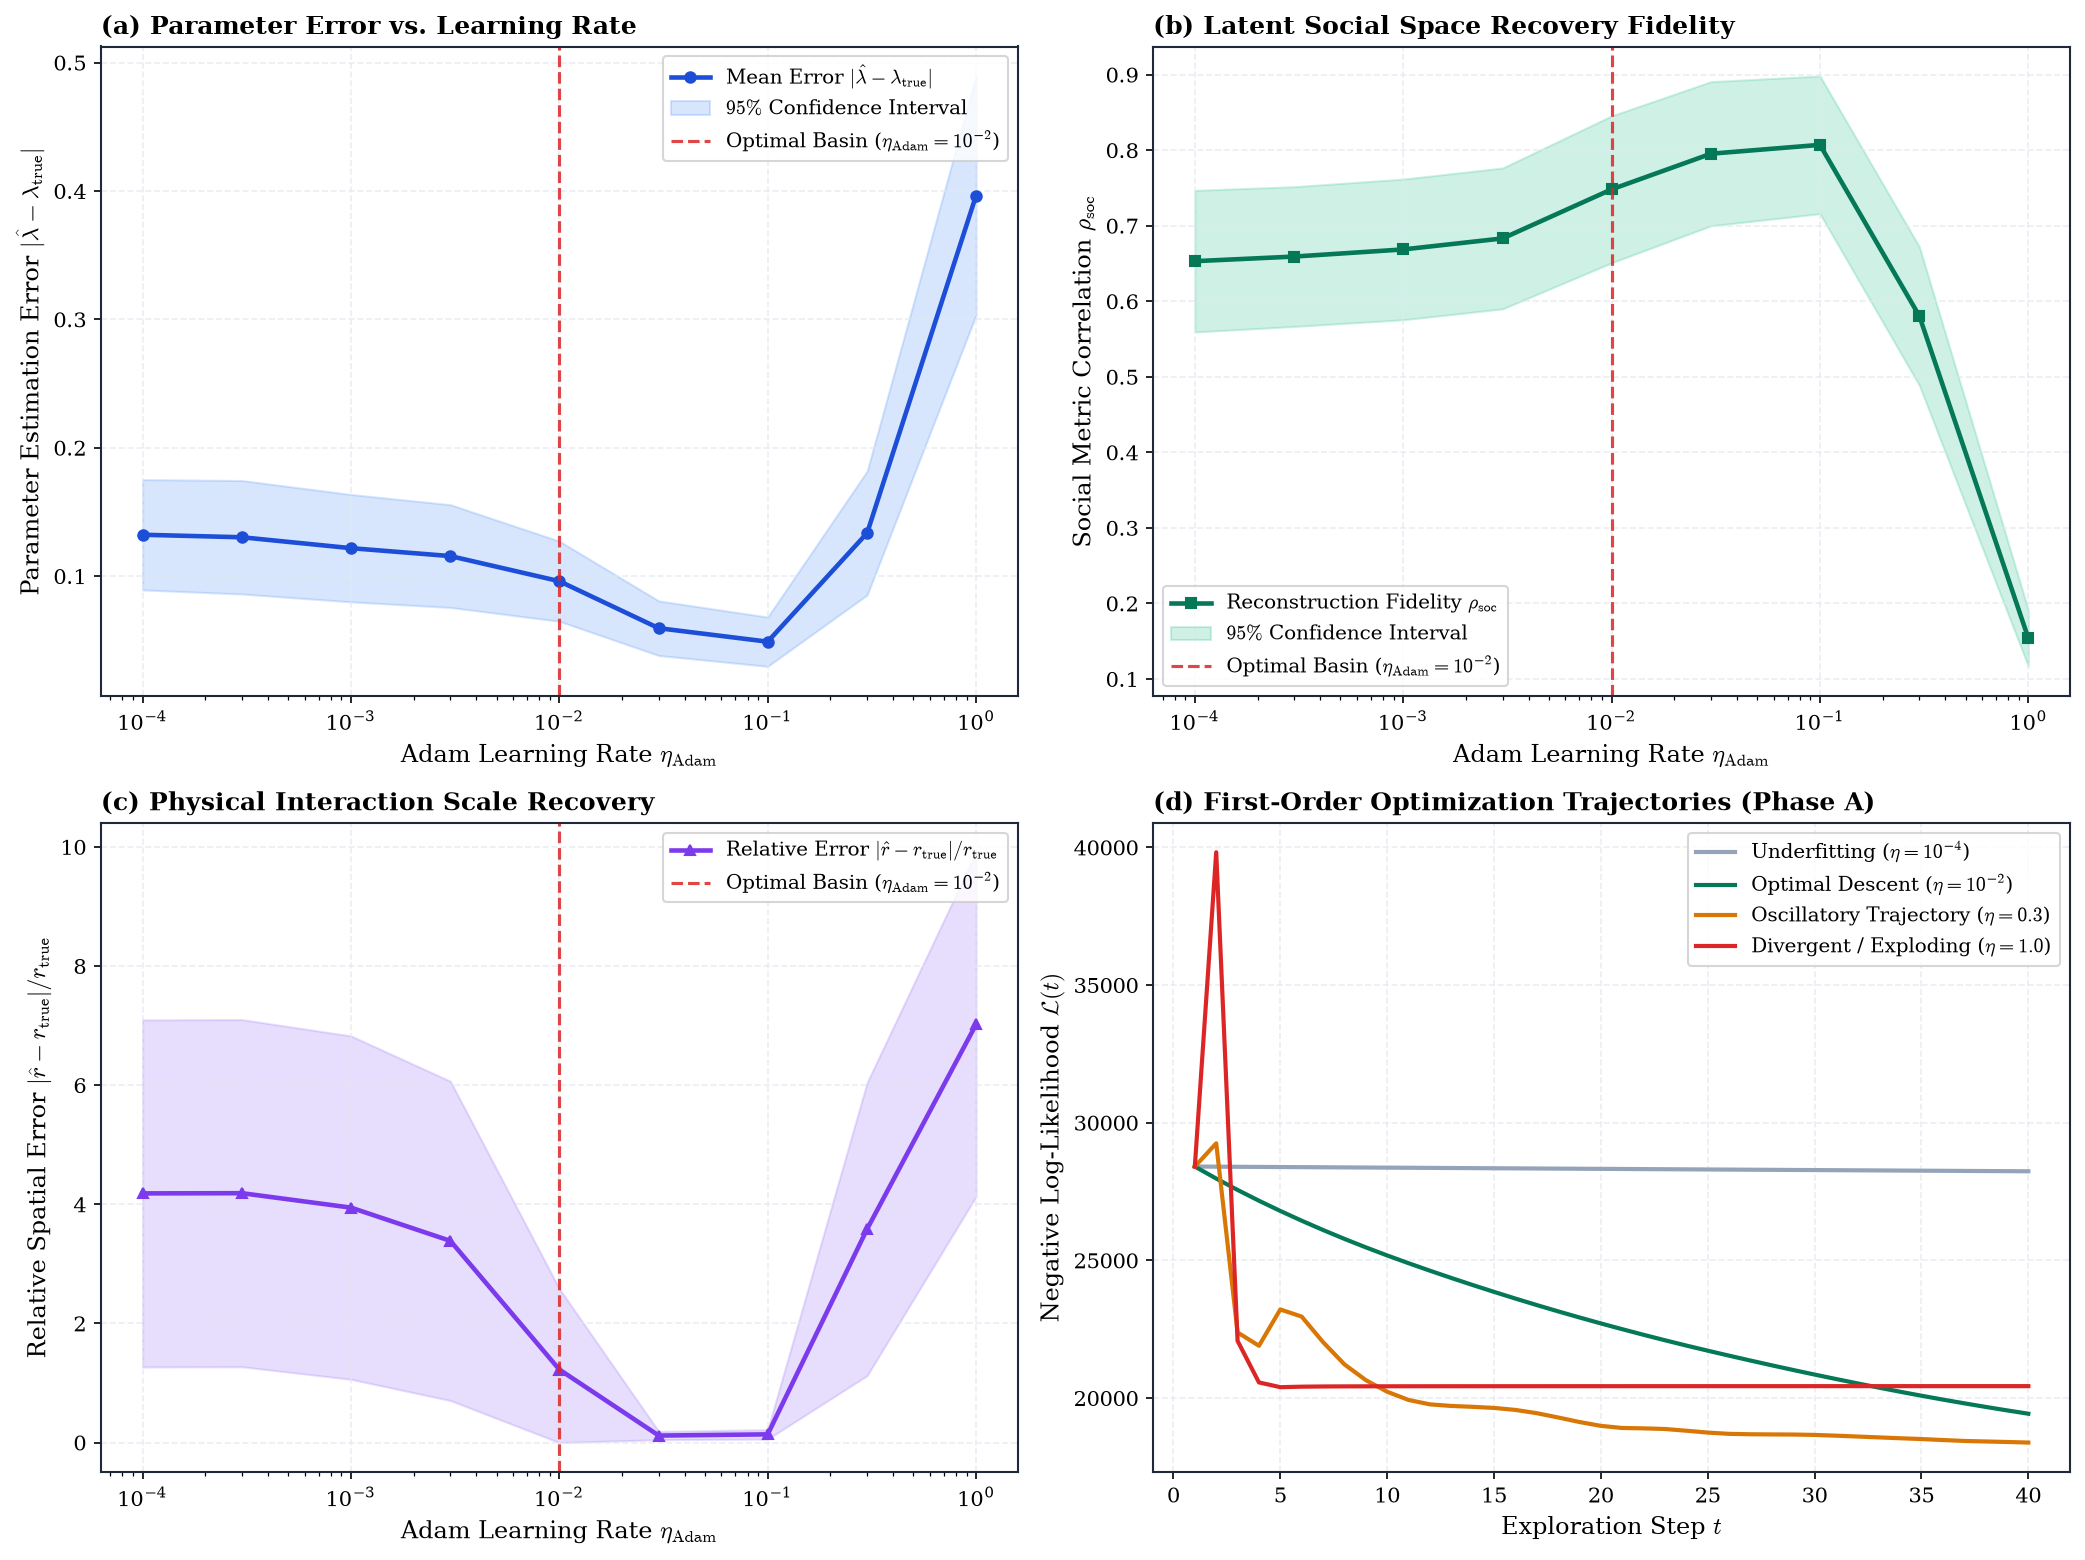

lr   err_lam             rho_soc           err_r_rel          
               mean       std      mean       std      mean       std
0  0.0001  0.132246  0.120050  0.653104  0.261931  4.183006  8.141469
1  0.0003  0.130282  0.123508  0.659215  0.258532  4.186479  8.142778
2  0.0010  0.121797  0.116843  0.668651  0.260191  3.944147  8.054852
3  0.0030  0.115629  0.111843  0.683223  0.260572  3.385854  7.489348
4  0.0100  0.096071  0.087205  0.748170  0.271709  1.225788  3.790121
5  0.0300  0.059448  0.059389  0.795374  0.266598  0.117461  0.194215
6  0.1000  0.048949  0.053635  0.807087  0.254657  0.137759  0.220681
7  0.3000  0.133569  0.134779  0.580427  0.256267  3.584823  6.875858
8  1.0000  0.396518  0.260112  0.154058  0.104115  7.020566  8.074071

In [1]:
# ======================================================================
# EXPERIMENT 1: LEARNING RATE SENSITIVITY ANALYSIS (eta_Adam in [10^-4, 1.0])
# ======================================================================

import os, time, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
from IPython.display import display

# Output directory resolution
output_dir = "Robustness_tests" if os.path.basename(os.getcwd()) != "Robustness_tests" else "."
os.makedirs(output_dir, exist_ok=True)

# LaTeX-style font formatting
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 11.5,
    "axes.titlesize": 12.0,
    "xtick.labelsize": 10.0,
    "ytick.labelsize": 10.0,
    "legend.fontsize": 9.5,
    "axes.edgecolor": "#1e293b",
    "axes.linewidth": 1.0,
    "grid.color": "#e2e8f0",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "figure.dpi": 150
})

device = torch.device("cpu")
torch.manual_seed(42); np.random.seed(42)

# --- Synthetic Network Generator ---
def sample_synthetic_network(N=None, lambda_true=None, r_true=None, sigma_true=None, d_s=2):
    if N is None:
        N = int(np.random.randint(100, 301))
    if lambda_true is None:
        lambda_true = float(np.random.uniform(0.05, 0.95))
    if r_true is None:
        r_true = float(np.exp(np.random.uniform(np.log(0.03), np.log(0.50))))
    if sigma_true is None:
        sigma_true = float(np.exp(np.random.uniform(np.log(0.03), np.log(0.50))))
    
    X_phys = np.random.uniform(0.0, 1.0, size=(N, 2))
    
    K = int(np.random.randint(2, 9))
    gmm_means = np.random.uniform(0.1, 0.9, size=(K, d_s))
    gmm_covs  = [np.diag(np.random.uniform(0.01, 0.05, size=d_s)) for _ in range(K)]
    weights   = np.random.dirichlet(np.ones(K))
    comp_choices = np.random.choice(K, size=N, p=weights)
    
    S_true = np.zeros((N, d_s))
    for k in range(K):
        idx_k = np.where(comp_choices == k)[0]
        if len(idx_k) > 0:
            S_true[idx_k] = np.random.multivariate_normal(gmm_means[k], gmm_covs[k], size=len(idx_k))
    S_min, S_max = S_true.min(axis=0), S_true.max(axis=0)
    S_true = (S_true - S_min) / (S_max - S_min + 1e-9)
    
    D_phys = cdist(X_phys, X_phys); np.fill_diagonal(D_phys, 1e9)
    D_soc  = cdist(S_true, S_true); np.fill_diagonal(D_soc, 1e9)
    
    K_sp  = np.exp(-D_phys / r_true);     np.fill_diagonal(K_sp, 0.0)
    K_soc = np.exp(-D_soc / sigma_true);  np.fill_diagonal(K_soc, 0.0)
    
    W_raw = (1.0 - lambda_true) * K_sp + lambda_true * K_soc
    row_sum = W_raw.sum(axis=1, keepdims=True) + 1e-12
    W_pred = 0.5 * (W_raw / row_sum + W_raw / row_sum.T)
    
    iu, ju = np.triu_indices(N, k=1)
    rate = N * W_pred[iu, ju]
    w_obs_u = np.random.poisson(rate).astype(float)
    
    W_obs = np.zeros((N, N))
    W_obs[iu, ju] = w_obs_u
    W_obs[ju, iu] = w_obs_u
    
    return {
        "N": N, "lambda_true": lambda_true, "r_true": r_true, "sigma_true": sigma_true,
        "D_phys": D_phys, "D_soc": D_soc, "S_true": S_true, "W_obs": W_obs
    }

# --- Sweep Parameters ---
N_BENCHMARK_NETWORKS = 30
lrs = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0] # Extended range up to 1.0
T_ADAM = 40
T_LBFGS = 40

tag = f"Nnets{N_BENCHMARK_NETWORKS}_Tadam{T_ADAM}_Tlbfgs{T_LBFGS}"
print(f"Executing Extended Learning Rate Sweep [{tag}] across {len(lrs)} rates...")
t_start = time.time()
records_lr = []
sample_loss_curves = {lr: [] for lr in [1e-4, 1e-2, 3e-1, 1.0]}

ensemble = [sample_synthetic_network() for _ in range(N_BENCHMARK_NETWORKS)]

for lr in lrs:
    t_lr = time.time()
    for net_idx, net in enumerate(ensemble):
        N = net["N"]; W = net["W_obs"]; D_phys = net["D_phys"]
        iu, ju = np.triu_indices(N, k=1)
        c_target = float(W.sum(axis=1).mean())
        r0 = float(2.0 * D_phys.min(axis=1).mean()); log_r0 = float(np.log(r0))
        
        D_phys_t = torch.tensor(D_phys, dtype=torch.float32, device=device)
        W_obs_u  = torch.tensor(W[iu, ju], dtype=torch.float32, device=device)
        iu_t, ju_t = torch.tensor(iu, dtype=torch.long, device=device), torch.tensor(ju, dtype=torch.long, device=device)
        eye_mask = 1.0 - torch.eye(N, device=device)
        
        # SVD Residual Initialization
        K_sp0 = np.exp(-D_phys / r0); np.fill_diagonal(K_sp0, 0.0)
        s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
        W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
        R_init = np.maximum(0.0, W - W_sp0)
        U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
        S_init = U[:, :2] * np.sqrt(sv[:2])
        S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0
        
        logit_lam = torch.tensor(0.0, requires_grad=True, device=device)
        log_r     = torch.tensor(log_r0, requires_grad=True, device=device)
        S_param   = torch.tensor(S_init, requires_grad=True, device=device)
        
        adam_losses = []
        adam_opt = torch.optim.Adam([
            {"params": [logit_lam], "lr": lr * 2.0},
            {"params": [log_r],     "lr": lr},
            {"params": [S_param],   "lr": lr * 5.0}
        ])
        for _ in range(T_ADAM):
            adam_opt.zero_grad()
            lam = torch.sigmoid(logit_lam); r = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
            K_sp = torch.exp(-D_phys_t / r) * eye_mask
            diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
            D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(N, device=device)
            K_soc = torch.exp(-D_soc / 1.0) * eye_mask
            W_raw_t = (1-lam)*K_sp + lam*K_soc
            rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
            W_pred_t = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
            wu = W_pred_t[iu_t, ju_t]
            loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
            loss.backward(); adam_opt.step()
            adam_losses.append(loss.item())
        
        if lr in sample_loss_curves and net_idx == 0:
            sample_loss_curves[lr] = adam_losses
            
        # L-BFGS Polish
        lbfgs = torch.optim.LBFGS([logit_lam, log_r, S_param], lr=0.5,
                                  max_iter=T_LBFGS, history_size=10, line_search_fn="strong_wolfe")
        def closure():
            lbfgs.zero_grad()
            lam = torch.sigmoid(logit_lam); r = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
            K_sp = torch.exp(-D_phys_t / r) * eye_mask
            diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
            D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(N, device=device)
            K_soc = torch.exp(-D_soc / 1.0) * eye_mask
            W_raw_t = (1-lam)*K_sp + lam*K_soc
            rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
            W_pred_t = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
            wu = W_pred_t[iu_t, ju_t]
            loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
            loss.backward(); return loss
        
        try:
            lbfgs.step(closure)
            lam_hat = float(torch.sigmoid(logit_lam).item())
            r_hat   = float(torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3)).item())
            err_lam = abs(lam_hat - net["lambda_true"])
            err_r_rel = abs(r_hat - net["r_true"]) / net["r_true"]
            
            S_hat = S_param.detach().cpu().numpy()
            D_soc_hat = cdist(S_hat, S_hat)[iu, ju]
            D_soc_gt  = net["D_soc"][iu, ju]
            rho_soc, _ = pearsonr(D_soc_hat, D_soc_gt)
        except Exception:
            err_lam = 1.0; err_r_rel = 10.0; rho_soc = 0.0
            
        records_lr.append({
            "network_idx": net_idx, "lr": lr, "err_lam": err_lam,
            "err_r_rel": err_r_rel, "rho_soc": rho_soc
        })
    print(f"  → η_Adam = {lr:7.1e} | |Δλ| = {np.mean([r['err_lam'] for r in records_lr if r['lr']==lr]):.4f} | ρ_soc = {np.mean([r['rho_soc'] for r in records_lr if r['lr']==lr]):.4f} ({time.time()-t_lr:.2f}s)")

# Save CSVs
df_raw = pd.DataFrame(records_lr)
raw_csv_path = f"{output_dir}/lr_sensitivity_raw_{tag}.csv"
df_raw.to_csv(raw_csv_path, index=False)

df_summary = df_raw.groupby("lr").agg({
    "err_lam": ["mean", "std"],
    "rho_soc": ["mean", "std"],
    "err_r_rel": ["mean", "std"]
}).reset_index()
summary_csv_path = f"{output_dir}/lr_sensitivity_summary_{tag}.csv"
df_summary.to_csv(summary_csv_path, index=False)
print(f"\nCalculations saved successfully:\n  • Raw: {raw_csv_path}\n  • Summary: {summary_csv_path}")

# --- Publication 4-Panel Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10.5))
lr_vals = df_summary["lr"].values

# (a) Parameter Estimation Error
ax1 = axes[0, 0]
m_lam = df_summary["err_lam"]["mean"].values
s_lam = df_summary["err_lam"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)
ax1.plot(lr_vals, m_lam, marker="o", color="#1d4ed8", lw=2.2, markersize=5, label=r"Mean Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$")
ax1.fill_between(lr_vals, m_lam - 1.96*s_lam, m_lam + 1.96*s_lam, color="#3b82f6", alpha=0.20, label=r"$95\%$ Confidence Interval")
ax1.axvline(1e-2, color="#dc2626", ls="--", lw=1.5, alpha=0.85, label=r"Optimal Basin ($\eta_{\mathrm{Adam}} = 10^{-2}$)")
ax1.set_xscale("log")
ax1.set_xlabel(r"Adam Learning Rate $\eta_{\mathrm{Adam}}$")
ax1.set_ylabel(r"Parameter Estimation Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$")
ax1.set_title("(a) Parameter Error vs. Learning Rate", loc="left", fontweight="bold")
ax1.grid(True); ax1.legend(loc="upper right")

# (b) Latent Social Metric Fidelity
ax2 = axes[0, 1]
m_rho = df_summary["rho_soc"]["mean"].values
s_rho = df_summary["rho_soc"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)
ax2.plot(lr_vals, m_rho, marker="s", color="#047857", lw=2.2, markersize=5, label=r"Reconstruction Fidelity $\rho_{\mathrm{soc}}$")
ax2.fill_between(lr_vals, m_rho - 1.96*s_rho, m_rho + 1.96*s_rho, color="#10b981", alpha=0.20, label=r"$95\%$ Confidence Interval")
ax2.axvline(1e-2, color="#dc2626", ls="--", lw=1.5, alpha=0.85, label=r"Optimal Basin ($\eta_{\mathrm{Adam}} = 10^{-2}$)")
ax2.set_xscale("log")
ax2.set_xlabel(r"Adam Learning Rate $\eta_{\mathrm{Adam}}$")
ax2.set_ylabel(r"Social Metric Correlation $\rho_{\mathrm{soc}}$")
ax2.set_title("(b) Latent Social Space Recovery Fidelity", loc="left", fontweight="bold")
ax2.grid(True); ax2.legend(loc="lower left")

# (c) Spatial Interaction Scale Error
ax3 = axes[1, 0]
m_r = df_summary["err_r_rel"]["mean"].values
s_r = df_summary["err_r_rel"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)
ax3.plot(lr_vals, m_r, marker="^", color="#7c3aed", lw=2.2, markersize=5, label=r"Relative Error $|\hat{r} - r_{\mathrm{true}}| / r_{\mathrm{true}}$")
ax3.fill_between(lr_vals, np.maximum(0, m_r - 1.96*s_r), m_r + 1.96*s_r, color="#8b5cf6", alpha=0.20)
ax3.axvline(1e-2, color="#dc2626", ls="--", lw=1.5, alpha=0.85, label=r"Optimal Basin ($\eta_{\mathrm{Adam}} = 10^{-2}$)")
ax3.set_xscale("log")
ax3.set_xlabel(r"Adam Learning Rate $\eta_{\mathrm{Adam}}$")
ax3.set_ylabel(r"Relative Spatial Error $|\hat{r} - r_{\mathrm{true}}| / r_{\mathrm{true}}$")
ax3.set_title("(c) Physical Interaction Scale Recovery", loc="left", fontweight="bold")
ax3.grid(True); ax3.legend(loc="upper right")

# (d) Optimization Trajectories
ax4 = axes[1, 1]
steps = np.arange(1, T_ADAM + 1)
colors_map = {1e-4: "#94a3b8", 1e-2: "#047857", 3e-1: "#d97706", 1.0: "#dc2626"}
labels_map = {
    1e-4: r"Underfitting ($\eta = 10^{-4}$)",
    1e-2: r"Optimal Descent ($\eta = 10^{-2}$)",
    3e-1: r"Oscillatory Trajectory ($\eta = 0.3$)",
    1.0:  r"Divergent / Exploding ($\eta = 1.0$)"
}
for lr_key in [1e-4, 1e-2, 3e-1, 1.0]:
    if len(sample_loss_curves[lr_key]) > 0:
        ax4.plot(steps, sample_loss_curves[lr_key], lw=2.0, color=colors_map[lr_key], label=labels_map[lr_key])
ax4.set_xlabel(r"Exploration Step $t$")
ax4.set_ylabel(r"Negative Log-Likelihood $\mathcal{L}(t)$")
ax4.set_title("(d) First-Order Optimization Trajectories (Phase A)", loc="left", fontweight="bold")
ax4.grid(True); ax4.legend(loc="upper right")

plt.tight_layout()

# Save publication figures
pdf_path = f"{output_dir}/lr_sensitivity_plot_{tag}.pdf"
png_path = f"{output_dir}/lr_sensitivity_plot_{tag}.png"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")
print(f"Figures exported:\n  • PDF: {pdf_path}\n  • PNG: {png_path}")

plt.show()
display(df_summary)


Precomputing 100 synthetic networks and SVD initializations...
Launching 2D Grid Sweep: 36 cells (6x6) on 8 CPU workers...
Cell     | η_Adam   | T_Adam | Mean MAE   | Mean ρ_soc | Cell Time  | Elapsed 
---------------------------------------------------------------------------
[ 1/36] | 0.01     | 10     | 0.1130     | 0.5649     | 18.62    s | 18.6   s
[ 2/36] | 0.01     | 20     | 0.1035     | 0.5862     | 12.80    s | 31.4   s
[ 3/36] | 0.01     | 30     | 0.0890     | 0.6118     | 14.51    s | 45.9   s
[ 4/36] | 0.01     | 40     | 0.0723     | 0.6458     | 15.72    s | 61.7   s
[ 5/36] | 0.01     | 50     | 0.0651     | 0.6619     | 17.52    s | 79.2   s
[ 6/36] | 0.01     | 60     | 0.0599     | 0.6743     | 18.14    s | 97.3   s
[ 7/36] | 0.02     | 10     | 0.1082     | 0.5829     | 10.94    s | 108.2  s
[ 8/36] | 0.02     | 20     | 0.0788     | 0.6327     | 10.41    s | 118.7  s
[ 9/36] | 0.02     | 30     | 0.0621     | 0.6687     | 12.63    s | 131.3  s
[10/36] | 0.02     |

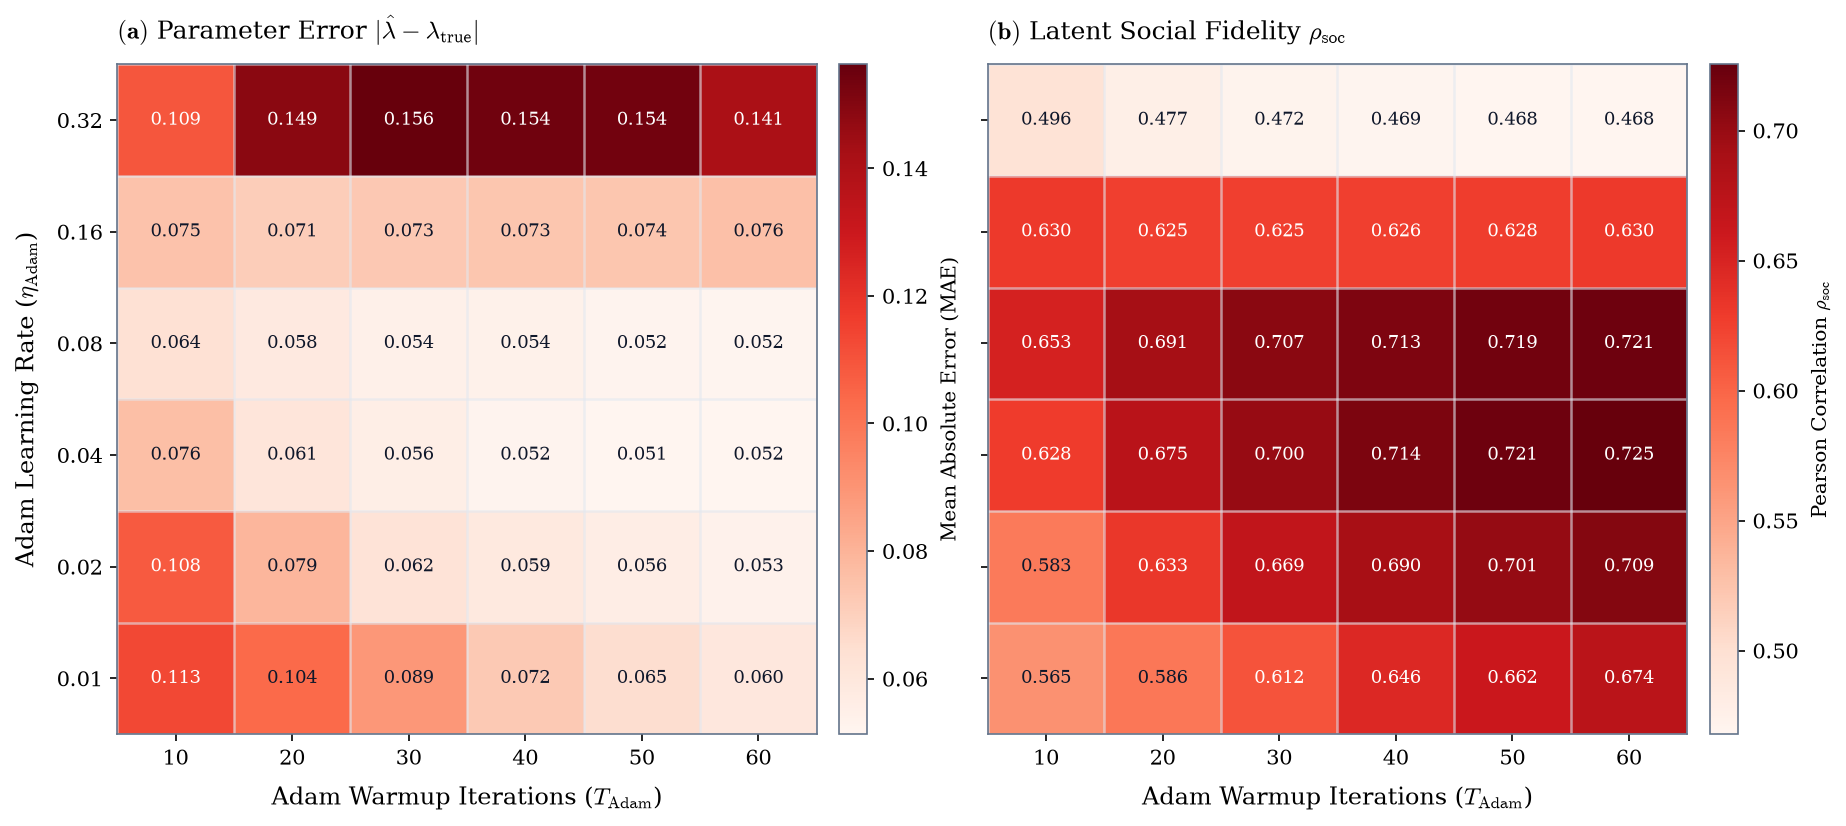


--- Parameter Error Matrix (MAE) ---


t_adam,10,20,30,40,50,60
lr,,,,,,
0.01,0.113007,0.103541,0.088999,0.072318,0.065069,0.059857
0.02,0.108192,0.078843,0.062144,0.058927,0.056220,0.053377
0.04,0.076172,0.061026,0.055755,0.052465,0.051306,0.051572
0.08,0.063530,0.058341,0.054488,0.053908,0.052192,0.051829
0.16,0.074935,0.070996,0.072902,0.073491,0.073807,0.075548
0.32,0.109498,0.148897,0.156290,0.153865,0.153793,0.140940



--- Latent Metric Fidelity Matrix (Pearson rho) ---


t_adam,10,20,30,40,50,60
lr,,,,,,
0.01,0.564922,0.586155,0.611840,0.645789,0.661855,0.674271
0.02,0.582892,0.632677,0.668682,0.689751,0.700810,0.709483
0.04,0.628460,0.675268,0.699929,0.713837,0.720588,0.725489
0.08,0.652878,0.691314,0.706739,0.712772,0.718645,0.720592
0.16,0.630194,0.625331,0.625413,0.625617,0.627699,0.629997
0.32,0.495751,0.477417,0.471744,0.469184,0.467863,0.468493


In [15]:
# ======================================================================
# 2D HYPERPARAMETER HEATMAP: eta_Adam vs. T_Adam JOINT SENSITIVITY GRID
# ======================================================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# --- 1. Worker ultra-ottimizzato (Zero overhead, single-thread forzato) ---
worker_code = '''import torch
import numpy as np
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr

# BLOCCA i thread interni di PyTorch per processo worker
torch.set_num_threads(1)

def _optimize_worker(task):
    lr, t_adam, net_item, T_LBFGS = task
    
    N = net_item["N"]
    c_target = net_item["c_target"]
    log_r0 = net_item["log_r0"]
    
    D_phys_t = torch.from_numpy(net_item["D_phys"]).float()
    W_obs_u  = torch.from_numpy(net_item["W_obs_u"]).float()
    iu_t     = torch.from_numpy(net_item["iu"]).long()
    ju_t     = torch.from_numpy(net_item["ju"]).long()
    eye_mask = torch.from_numpy(net_item["eye_mask"]).float()
    
    logit_lam = torch.tensor(0.0, requires_grad=True)
    log_r     = torch.tensor(log_r0, requires_grad=True)
    S_param   = torch.from_numpy(net_item["S_init"]).float().requires_grad_(True)
    
    adam_opt = torch.optim.Adam([
        {"params": [logit_lam], "lr": lr * 2.0},
        {"params": [log_r],     "lr": lr},
        {"params": [S_param],   "lr": lr * 5.0}
    ])
    
    # 1. Warmup con Adam
    for _ in range(t_adam):
        adam_opt.zero_grad(set_to_none=True)
        lam = torch.sigmoid(logit_lam)
        r = torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0))
        
        K_sp = torch.exp(-D_phys_t / r) * eye_mask
        D_soc = torch.cdist(S_param, S_param)
        K_soc = torch.exp(-D_soc) * eye_mask
        
        W_raw_t = (1.0 - lam) * K_sp + lam * K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred_t = 0.5 * c_target * (W_raw_t / rs + W_raw_t / rs.t())
        
        wu = W_pred_t[iu_t, ju_t]
        loss = (wu - W_obs_u * torch.log(wu + 1e-12)).sum() + 0.5 * ((log_r - log_r0) / 2.0)**2
        loss.backward()
        adam_opt.step()
        
    # 2. Rifinitura con L-BFGS
    lbfgs = torch.optim.LBFGS(
        [logit_lam, log_r, S_param], 
        lr=0.5, 
        max_iter=T_LBFGS, 
        history_size=10, 
        line_search_fn="strong_wolfe"
    )
    
    def closure():
        lbfgs.zero_grad(set_to_none=True)
        lam = torch.sigmoid(logit_lam)
        r = torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0))
        
        K_sp = torch.exp(-D_phys_t / r) * eye_mask
        D_soc = torch.cdist(S_param, S_param)
        K_soc = torch.exp(-D_soc) * eye_mask
        
        W_raw_t = (1.0 - lam) * K_sp + lam * K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred_t = 0.5 * c_target * (W_raw_t / rs + W_raw_t / rs.t())
        
        wu = W_pred_t[iu_t, ju_t]
        loss = (wu - W_obs_u * torch.log(wu + 1e-12)).sum() + 0.5 * ((log_r - log_r0) / 2.0)**2
        loss.backward()
        return loss
    
    try:
        lbfgs.step(closure)
        lam_hat = float(torch.sigmoid(logit_lam).item())
        err_lam = abs(lam_hat - net_item["lambda_true"])
        S_hat = S_param.detach().numpy()
        D_soc_hat = cdist(S_hat, S_hat)[net_item["iu"], net_item["ju"]]
        D_soc_gt  = net_item["D_soc_flat"]
        rho_soc, _ = pearsonr(D_soc_hat, D_soc_gt)
        if np.isnan(rho_soc):
            rho_soc = 0.0
    except Exception:
        err_lam = 1.0
        rho_soc = 0.0
        
    return {"lr": lr, "t_adam": t_adam, "err_lam": err_lam, "rho_soc": rho_soc}
'''

with open("_opt_worker.py", "w") as f:
    f.write(worker_code)

from _opt_worker import _optimize_worker

import time, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial.distance import cdist
from concurrent.futures import ProcessPoolExecutor
from IPython.display import display

# Output directory resolution
output_dir = "Robustness_tests" if os.path.basename(os.getcwd()) != "Robustness_tests" else "."
os.makedirs(output_dir, exist_ok=True)

# LaTeX-style font formatting
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 11.5,
    "axes.titlesize": 12.0,
    "xtick.labelsize": 10.0,
    "ytick.labelsize": 10.0,
    "legend.fontsize": 9.0,
    "axes.edgecolor": "#64748b",
    "axes.linewidth": 0.8,
    "figure.dpi": 150
})

# --- Synthetic Network Generator ---
def sample_synthetic_network(N=None, lambda_true=None, r_true=None, sigma_true=None, d_s=2, seed=None):
    if seed is not None:
        np.random.seed(seed)
    if N is None:
        N = int(np.random.randint(100, 250))
    if lambda_true is None:
        lambda_true = float(np.random.uniform(0.05, 0.95))
    if r_true is None:
        r_true = float(np.exp(np.random.uniform(np.log(0.03), np.log(0.50))))
    if sigma_true is None:
        sigma_true = float(np.exp(np.random.uniform(np.log(0.03), np.log(0.50))))
    
    X_phys = np.random.uniform(0.0, 1.0, size=(N, 2))
    
    K = int(np.random.randint(2, 9))
    gmm_means = np.random.uniform(0.1, 0.9, size=(K, d_s))
    gmm_covs  = [np.diag(np.random.uniform(0.01, 0.05, size=d_s)) for _ in range(K)]
    weights   = np.random.dirichlet(np.ones(K))
    comp_choices = np.random.choice(K, size=N, p=weights)
    
    S_true = np.zeros((N, d_s))
    for k in range(K):
        idx_k = np.where(comp_choices == k)[0]
        if len(idx_k) > 0:
            S_true[idx_k] = np.random.multivariate_normal(gmm_means[k], gmm_covs[k], size=len(idx_k))
    S_min, S_max = S_true.min(axis=0), S_true.max(axis=0)
    S_true = (S_true - S_min) / (S_max - S_min + 1e-9)
    
    D_phys = cdist(X_phys, X_phys); np.fill_diagonal(D_phys, 1e9)
    D_soc  = cdist(S_true, S_true); np.fill_diagonal(D_soc, 1e9)
    
    K_sp  = np.exp(-D_phys / r_true);     np.fill_diagonal(K_sp, 0.0)
    K_soc = np.exp(-D_soc / sigma_true);  np.fill_diagonal(K_soc, 0.0)
    
    W_raw = (1.0 - lambda_true) * K_sp + lambda_true * K_soc
    row_sum = W_raw.sum(axis=1, keepdims=True) + 1e-12
    W_pred = 0.5 * (W_raw / row_sum + W_raw / row_sum.T)
    
    iu, ju = np.triu_indices(N, k=1)
    rate = N * W_pred[iu, ju]
    w_obs_u = np.random.poisson(rate).astype(float)
    
    W_obs = np.zeros((N, N))
    W_obs[iu, ju] = w_obs_u
    W_obs[ju, iu] = w_obs_u
    
    return {
        "N": N, "lambda_true": lambda_true, "r_true": r_true, "sigma_true": sigma_true,
        "D_phys": D_phys, "D_soc": D_soc, "S_true": S_true, "W_obs": W_obs
    }

# --- 6x6 Grid Hyperparameters ---
lrs = [0.01, 0.02, 0.04, 0.08, 0.16, 0.32]
t_adams = [10, 20, 30, 40, 50, 60]
N_BENCHMARK_NETWORKS = 100
T_LBFGS = 40

tag = f"2DGrid_6x6_eta{lrs[0]:.2f}-{lrs[-1]:.2f}_Tadam{t_adams[0]}-{t_adams[-1]}_Nnets{N_BENCHMARK_NETWORKS}_Tlbfgs{T_LBFGS}"

print(f"Precomputing {N_BENCHMARK_NETWORKS} synthetic networks and SVD initializations...")
ensemble_precomputed = []
for i in range(N_BENCHMARK_NETWORKS):
    net = sample_synthetic_network(seed=500 + i)
    N = net["N"]; W = net["W_obs"]; D_phys = net["D_phys"]
    iu, ju = np.triu_indices(N, k=1)
    c_target = float(W.sum(axis=1).mean())
    r0 = float(2.0 * D_phys.min(axis=1).mean()); log_r0 = float(np.log(r0))
    
    K_sp0 = np.exp(-D_phys / r0); np.fill_diagonal(K_sp0, 0.0)
    s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
    W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
    R_init = np.maximum(0.0, W - W_sp0)
    U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
    S_init = U[:, :2] * np.sqrt(sv[:2])
    S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0
    
    ensemble_precomputed.append({
        "N": N, "lambda_true": net["lambda_true"], "c_target": c_target, "log_r0": log_r0,
        "D_phys": D_phys.astype(np.float32),
        "W_obs_u": W[iu, ju].astype(np.float32),
        "iu": iu.astype(np.int64), "ju": ju.astype(np.int64),
        "eye_mask": (1.0 - np.eye(N)).astype(np.float32),
        "S_init": S_init.astype(np.float32),
        "D_soc_flat": net["D_soc"][iu, ju].astype(np.float64)
    })

total_cells = len(lrs) * len(t_adams)
num_workers = os.cpu_count() or 4
print(f"Launching 2D Grid Sweep: {total_cells} cells ({len(lrs)}x{len(t_adams)}) on {num_workers} CPU workers...")
print(f"{'Cell':<8} | {'η_Adam':<8} | {'T_Adam':<6} | {'Mean MAE':<10} | {'Mean ρ_soc':<10} | {'Cell Time':<10} | {'Elapsed':<8}")
print("-" * 75)

t_start = time.time()
records_2d = []
cell_idx = 0

with ProcessPoolExecutor(max_workers=num_workers) as executor:
    for lr in lrs:
        for t_adam in t_adams:
            cell_idx += 1
            t_cell_start = time.time()
            
            cell_tasks = [(lr, t_adam, net_item, T_LBFGS) for net_item in ensemble_precomputed]
            cell_results = list(executor.map(_optimize_worker, cell_tasks, chunksize=8))
            
            records_2d.extend(cell_results)
            
            cell_mae = np.mean([r["err_lam"] for r in cell_results])
            cell_rho = np.mean([r["rho_soc"] for r in cell_results])
            t_cell = time.time() - t_cell_start
            t_elapsed = time.time() - t_start
            
            print(f"[{cell_idx:2d}/{total_cells}] | {lr:<8.2f} | {t_adam:<6d} | {cell_mae:<10.4f} | {cell_rho:<10.4f} | {t_cell:<9.2f}s | {t_elapsed:<7.1f}s")

print("-" * 75)
print(f"2D Sweep completed in {time.time() - t_start:.2f}s.")

# Build Pivot Matrices
df_grid = pd.DataFrame(records_2d)
pivot_lam = df_grid.pivot_table(index="lr", columns="t_adam", values="err_lam", aggfunc="mean")
pivot_rho = df_grid.pivot_table(index="lr", columns="t_adam", values="rho_soc", aggfunc="mean")

# --- Export CSVs & Integrity Check ---
raw_csv_path = os.path.join(output_dir, f"2d_heatmap_raw_{tag}.csv")
lam_csv_path = os.path.join(output_dir, f"2d_heatmap_matrix_err_lam_{tag}.csv")
rho_csv_path = os.path.join(output_dir, f"2d_heatmap_matrix_rho_soc_{tag}.csv")

df_grid.to_csv(raw_csv_path, index=False)
pivot_lam.to_csv(lam_csv_path)
pivot_rho.to_csv(rho_csv_path)

print("\n--- CSV Export Verification ---")
for p in [raw_csv_path, lam_csv_path, rho_csv_path]:
    if os.path.isfile(p):
        size_kb = os.path.getsize(p) / 1024
        print(f"  [OK] Saved: {os.path.basename(p):<60} ({size_kb:.1f} KB)")
    else:
        raise FileNotFoundError(f"Export check failed for {p}")

# --- Publication 2-Panel Heatmap Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), sharey=True)

lr_labels = [f"{lr:.2f}" for lr in lrs]
t_labels = [str(t) for t in t_adams]

cmap_reds = plt.colormaps.get_cmap("Reds")

def dynamic_text_color(val, norm, cmap):
    rgba = cmap(norm(val))
    luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
    return "#ffffff" if luminance < 0.52 else "#0f172a"

# Panel 1: Parameter Estimation Error
norm1 = mcolors.Normalize(vmin=np.nanmin(pivot_lam.values), vmax=np.nanmax(pivot_lam.values))
im1 = axes[0].imshow(pivot_lam.values, cmap=cmap_reds, norm=norm1, aspect="auto", origin="lower")

axes[0].set_xticks(range(len(t_adams)))
axes[0].set_xticklabels(t_labels, fontweight="medium")
axes[0].set_yticks(range(len(lrs)))
axes[0].set_yticklabels(lr_labels, fontweight="medium")
axes[0].set_xlabel(r"Adam Warmup Iterations ($T_{\mathrm{Adam}}$)", labelpad=8)
axes[0].set_ylabel(r"Adam Learning Rate ($\eta_{\mathrm{Adam}}$)", labelpad=8)
axes[0].set_title(r"$\mathbf{(a)}$ Parameter Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$", loc="left", pad=12)

axes[0].set_xticks(np.arange(-.5, len(t_adams), 1), minor=True)
axes[0].set_yticks(np.arange(-.5, len(lrs), 1), minor=True)
axes[0].grid(which="minor", color="#e2e8f0", linestyle="-", linewidth=1.2, alpha=0.6)
axes[0].tick_params(which="minor", bottom=False, left=False)

cbar1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.03, aspect=24)
cbar1.set_label(r"Mean Absolute Error (MAE)", fontsize=9.5, labelpad=6)
cbar1.outline.set_linewidth(0.8)

for i in range(len(lrs)):
    for j in range(len(t_adams)):
        val = pivot_lam.values[i, j]
        txt_color = dynamic_text_color(val, norm1, cmap_reds)
        axes[0].text(j, i, f"{val:.3f}", ha="center", va="center", 
                     color=txt_color, fontsize=8.5, fontweight="medium")

# Panel 2: Latent Social Space Recovery
norm2 = mcolors.Normalize(vmin=np.nanmin(pivot_rho.values), vmax=np.nanmax(pivot_rho.values))
im2 = axes[1].imshow(pivot_rho.values, cmap=cmap_reds, norm=norm2, aspect="auto", origin="lower")

axes[1].set_xticks(range(len(t_adams)))
axes[1].set_xticklabels(t_labels, fontweight="medium")
axes[1].set_xlabel(r"Adam Warmup Iterations ($T_{\mathrm{Adam}}$)", labelpad=8)
axes[1].set_title(r"$\mathbf{(b)}$ Latent Social Fidelity $\rho_{\mathrm{soc}}$", loc="left", pad=12)

axes[1].set_xticks(np.arange(-.5, len(t_adams), 1), minor=True)
axes[1].set_yticks(np.arange(-.5, len(lrs), 1), minor=True)
axes[1].grid(which="minor", color="#e2e8f0", linestyle="-", linewidth=1.2, alpha=0.6)
axes[1].tick_params(which="minor", bottom=False, left=False)

cbar2 = fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.03, aspect=24)
cbar2.set_label(r"Pearson Correlation $\rho_{\mathrm{soc}}$", fontsize=9.5, labelpad=6)
cbar2.outline.set_linewidth(0.8)

for i in range(len(lrs)):
    for j in range(len(t_adams)):
        val = pivot_rho.values[i, j]
        txt_color = dynamic_text_color(val, norm2, cmap_reds)
        axes[1].text(j, i, f"{val:.3f}", ha="center", va="center", 
                     color=txt_color, fontsize=8.5, fontweight="medium")

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color("#64748b")
        spine.set_linewidth(0.8)

plt.subplots_adjust(wspace=0.15)

# --- Save Publication Figures & Check ---
pdf_path = os.path.join(output_dir, f"2d_heatmap_plot_{tag}.pdf")
png_path = os.path.join(output_dir, f"2d_heatmap_plot_{tag}.png")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")

print("\n--- Figure Export Verification ---")
for fpath in [pdf_path, png_path]:
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  [OK] Saved: {os.path.basename(fpath):<60} ({size_kb:.1f} KB)")
    else:
        raise FileNotFoundError(f"Export check failed for {fpath}")

plt.show()

print("\n--- Parameter Error Matrix (MAE) ---")
display(pivot_lam)
print("\n--- Latent Metric Fidelity Matrix (Pearson rho) ---")
display(pivot_rho)

Caricamento dati da: ./2d_heatmap_raw_2DGrid_6x6_eta0.01-0.32_Tadam10-60_Nnets100_Tlbfgs40.csv

--- Figure Export Verification ---
  [OK] Saved: 2d_heatmap_plot_vertical_square_2DGrid_6x6_eta0.01-0.32_Tadam10-60_Nnets100_Tlbfgs40.pdf (47.8 KB)
  [OK] Saved: 2d_heatmap_plot_vertical_square_2DGrid_6x6_eta0.01-0.32_Tadam10-60_Nnets100_Tlbfgs40.png (574.4 KB)


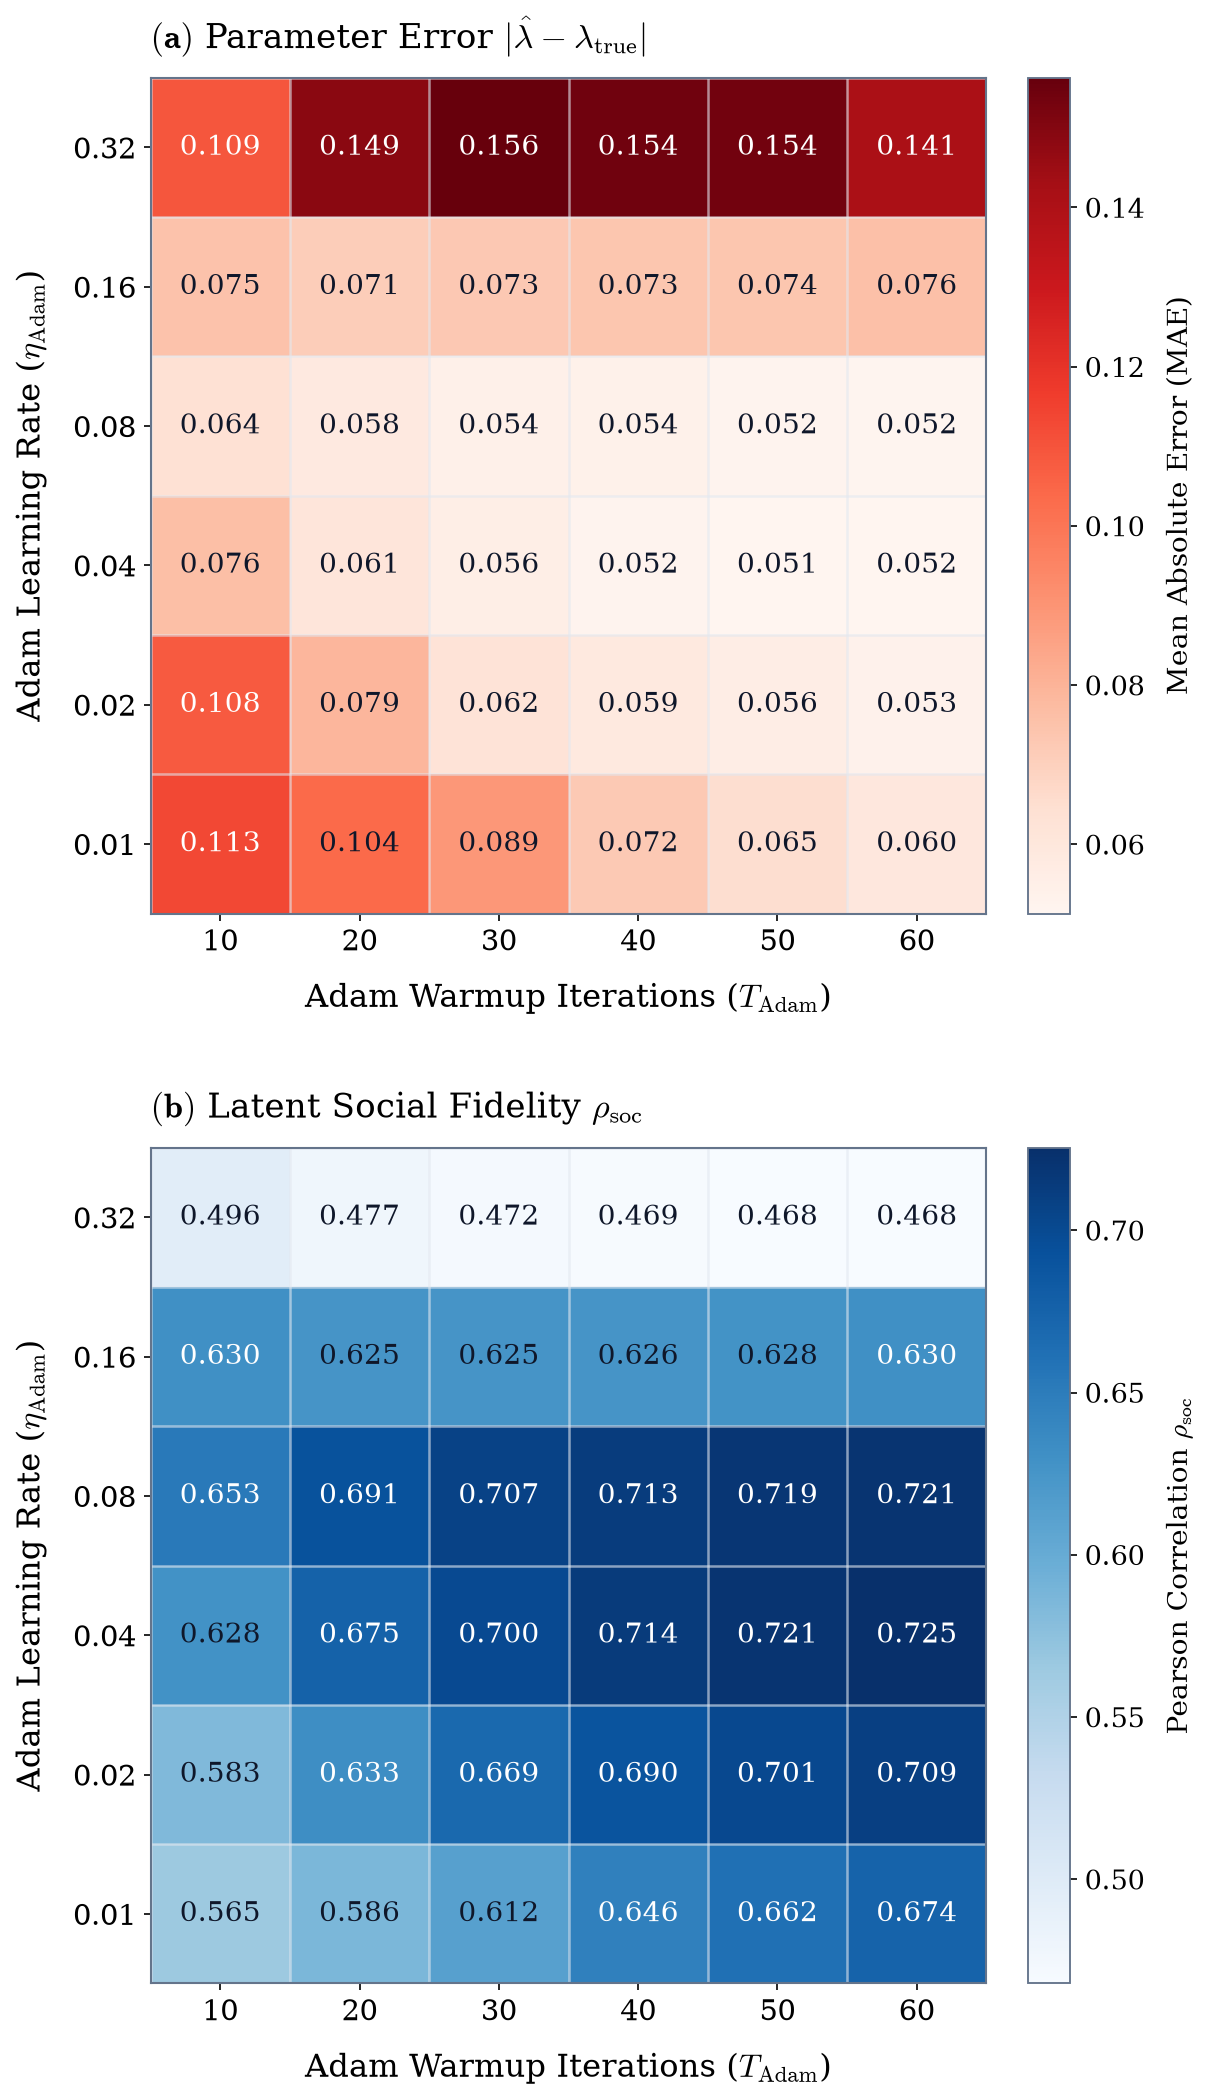

In [19]:
# ======================================================================
# RE-PLOT VERTICAL SQUARE HEATMAPS (NO ERRORS, LARGE FONTS, NO WARNINGS)
# ======================================================================

import os, glob
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Output directory resolution
output_dir = "Robustness_tests" if os.path.basename(os.getcwd()) != "Robustness_tests" else "."

# --- 1. Grid Parameters & CSV Resolution ---
lrs = [0.01, 0.02, 0.04, 0.08, 0.16, 0.32]
t_adams = [10, 20, 30, 40, 50, 60]
N_BENCHMARK_NETWORKS = 100
T_LBFGS = 40

tag = f"2DGrid_6x6_eta{lrs[0]:.2f}-{lrs[-1]:.2f}_Tadam{t_adams[0]}-{t_adams[-1]}_Nnets{N_BENCHMARK_NETWORKS}_Tlbfgs{T_LBFGS}"
raw_csv_path = os.path.join(output_dir, f"2d_heatmap_raw_{tag}.csv")

if not os.path.exists(raw_csv_path):
    candidates = glob.glob(os.path.join(output_dir, "2d_heatmap_raw_*.csv"))
    if candidates:
        raw_csv_path = max(candidates, key=os.path.getmtime)
        print(f"Caricamento automatico dall'ultimo CSV disponibile: {raw_csv_path}")
    else:
        raise FileNotFoundError(f"Nessun file CSV raw trovato in '{output_dir}/'.")
else:
    print(f"Caricamento dati da: {raw_csv_path}")

df_grid = pd.read_csv(raw_csv_path)

# --- 2. Statistical Aggregation (Mean only) ---
pivot_lam_mean = df_grid.pivot_table(index="lr", columns="t_adam", values="err_lam", aggfunc="mean").reindex(index=lrs, columns=t_adams)
pivot_rho_mean = df_grid.pivot_table(index="lr", columns="t_adam", values="rho_soc", aggfunc="mean").reindex(index=lrs, columns=t_adams)

# --- 3. Plotting Setup (Tipografia Maggiorata & No Font Warnings) ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 15.5,
    "axes.titlesize": 16.5,
    "xtick.labelsize": 14.0,
    "ytick.labelsize": 14.0,
    "axes.edgecolor": "#64748b",
    "axes.linewidth": 1.0,
    "figure.dpi": 150
})

# Layout verticale proporzionato per subplot quadrati (aspect="equal")
fig, axes = plt.subplots(2, 1, figsize=(9.0, 16.5))

lr_labels = [f"{lr:.2f}" for lr in lrs]
t_labels = [str(t) for t in t_adams]

cmap_err = plt.colormaps.get_cmap("Reds")
cmap_fid = plt.colormaps.get_cmap("Blues")

def dynamic_text_color(val, norm, cmap):
    rgba = cmap(norm(val))
    luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
    return "#ffffff" if luminance < 0.52 else "#0f172a"

# ==========================================
# Panel 1 (Top): Parameter Estimation Error (MAE) - REDS
# ==========================================
norm1 = mcolors.Normalize(vmin=np.nanmin(pivot_lam_mean.values), vmax=np.nanmax(pivot_lam_mean.values))
im1 = axes[0].imshow(pivot_lam_mean.values, cmap=cmap_err, norm=norm1, aspect="equal", origin="lower")

axes[0].set_xticks(range(len(t_adams)))
axes[0].set_xticklabels(t_labels)
axes[0].set_yticks(range(len(lrs)))
axes[0].set_yticklabels(lr_labels)
axes[0].set_xlabel(r"Adam Warmup Iterations ($T_{\mathrm{Adam}}$)", labelpad=12)
axes[0].set_ylabel(r"Adam Learning Rate ($\eta_{\mathrm{Adam}}$)", labelpad=12)
axes[0].set_title(r"$\mathbf{(a)}$ Parameter Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$", loc="left", pad=14)

axes[0].set_xticks(np.arange(-.5, len(t_adams), 1), minor=True)
axes[0].set_yticks(np.arange(-.5, len(lrs), 1), minor=True)
axes[0].grid(which="minor", color="#e2e8f0", linestyle="-", linewidth=1.2, alpha=0.6)
axes[0].tick_params(which="minor", bottom=False, left=False)

cbar1 = fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, aspect=20)
cbar1.set_label(r"Mean Absolute Error (MAE)", fontsize=13.5, labelpad=10)
cbar1.ax.tick_params(labelsize=13.0)
cbar1.outline.set_linewidth(0.9)

for i in range(len(lrs)):
    for j in range(len(t_adams)):
        val = pivot_lam_mean.values[i, j]
        txt_color = dynamic_text_color(val, norm1, cmap_err)
        axes[0].text(j, i, f"{val:.3f}", 
                     ha="center", va="center", color=txt_color, 
                     fontsize=13.5)

# ==========================================
# Panel 2 (Bottom): Latent Social Space Recovery - BLUES
# ==========================================
norm2 = mcolors.Normalize(vmin=np.nanmin(pivot_rho_mean.values), vmax=np.nanmax(pivot_rho_mean.values))
im2 = axes[1].imshow(pivot_rho_mean.values, cmap=cmap_fid, norm=norm2, aspect="equal", origin="lower")

axes[1].set_xticks(range(len(t_adams)))
axes[1].set_xticklabels(t_labels)
axes[1].set_yticks(range(len(lrs)))
axes[1].set_yticklabels(lr_labels)
axes[1].set_xlabel(r"Adam Warmup Iterations ($T_{\mathrm{Adam}}$)", labelpad=12)
axes[1].set_ylabel(r"Adam Learning Rate ($\eta_{\mathrm{Adam}}$)", labelpad=12)
axes[1].set_title(r"$\mathbf{(b)}$ Latent Social Fidelity $\rho_{\mathrm{soc}}$", loc="left", pad=14)

axes[1].set_xticks(np.arange(-.5, len(t_adams), 1), minor=True)
axes[1].set_yticks(np.arange(-.5, len(lrs), 1), minor=True)
axes[1].grid(which="minor", color="#e2e8f0", linestyle="-", linewidth=1.2, alpha=0.6)
axes[1].tick_params(which="minor", bottom=False, left=False)

cbar2 = fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, aspect=20)
cbar2.set_label(r"Pearson Correlation $\rho_{\mathrm{soc}}$", fontsize=13.5, labelpad=10)
cbar2.ax.tick_params(labelsize=13.0)
cbar2.outline.set_linewidth(0.9)

for i in range(len(lrs)):
    for j in range(len(t_adams)):
        val = pivot_rho_mean.values[i, j]
        txt_color = dynamic_text_color(val, norm2, cmap_fid)
        axes[1].text(j, i, f"{val:.3f}", 
                     ha="center", va="center", color=txt_color, 
                     fontsize=13.5)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color("#64748b")
        spine.set_linewidth(1.0)

plt.subplots_adjust(hspace=0.28)

# --- 4. Export PDF & PNG ---
pdf_path = os.path.join(output_dir, f"2d_heatmap_plot_vertical_square_{tag}.pdf")
png_path = os.path.join(output_dir, f"2d_heatmap_plot_vertical_square_{tag}.png")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")

print("\n--- Figure Export Verification ---")
for fpath in [pdf_path, png_path]:
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  [OK] Saved: {os.path.basename(fpath):<60} ({size_kb:.1f} KB)")

plt.show()

<h4>$\epsilon$-noise test</h4>

Precomputing 100 base synthetic networks...
Launching Topological Epsilon-Noise Stress Test across 8 noise levels on 8 CPU workers...
Noise (ε)    | Mean |Δλ|    | Mean ρ_soc   | Mean Δr/r    | Level Time  | Elapsed 
------------------------------------------------------------------------------
ε = 0.00     | 0.0408       | 0.7939       | 0.0793       | 42.08     s | 42.1   s
ε = 0.05     | 0.0395       | 0.7879       | 0.1544       | 28.36     s | 70.4   s
ε = 0.10     | 0.0461       | 0.7802       | 0.3197       | 27.78     s | 98.2   s
ε = 0.15     | 0.0512       | 0.7557       | 0.6104       | 26.52     s | 124.7  s
ε = 0.20     | 0.0617       | 0.7453       | 0.9037       | 29.65     s | 154.4  s
ε = 0.30     | 0.0758       | 0.6999       | 1.6126       | 25.66     s | 180.0  s
ε = 0.40     | 0.0841       | 0.6391       | 1.3707       | 26.16     s | 206.2  s
ε = 0.50     | 0.0972       | 0.5704       | 1.0976       | 27.94     s | 234.2  s
----------------------------------------

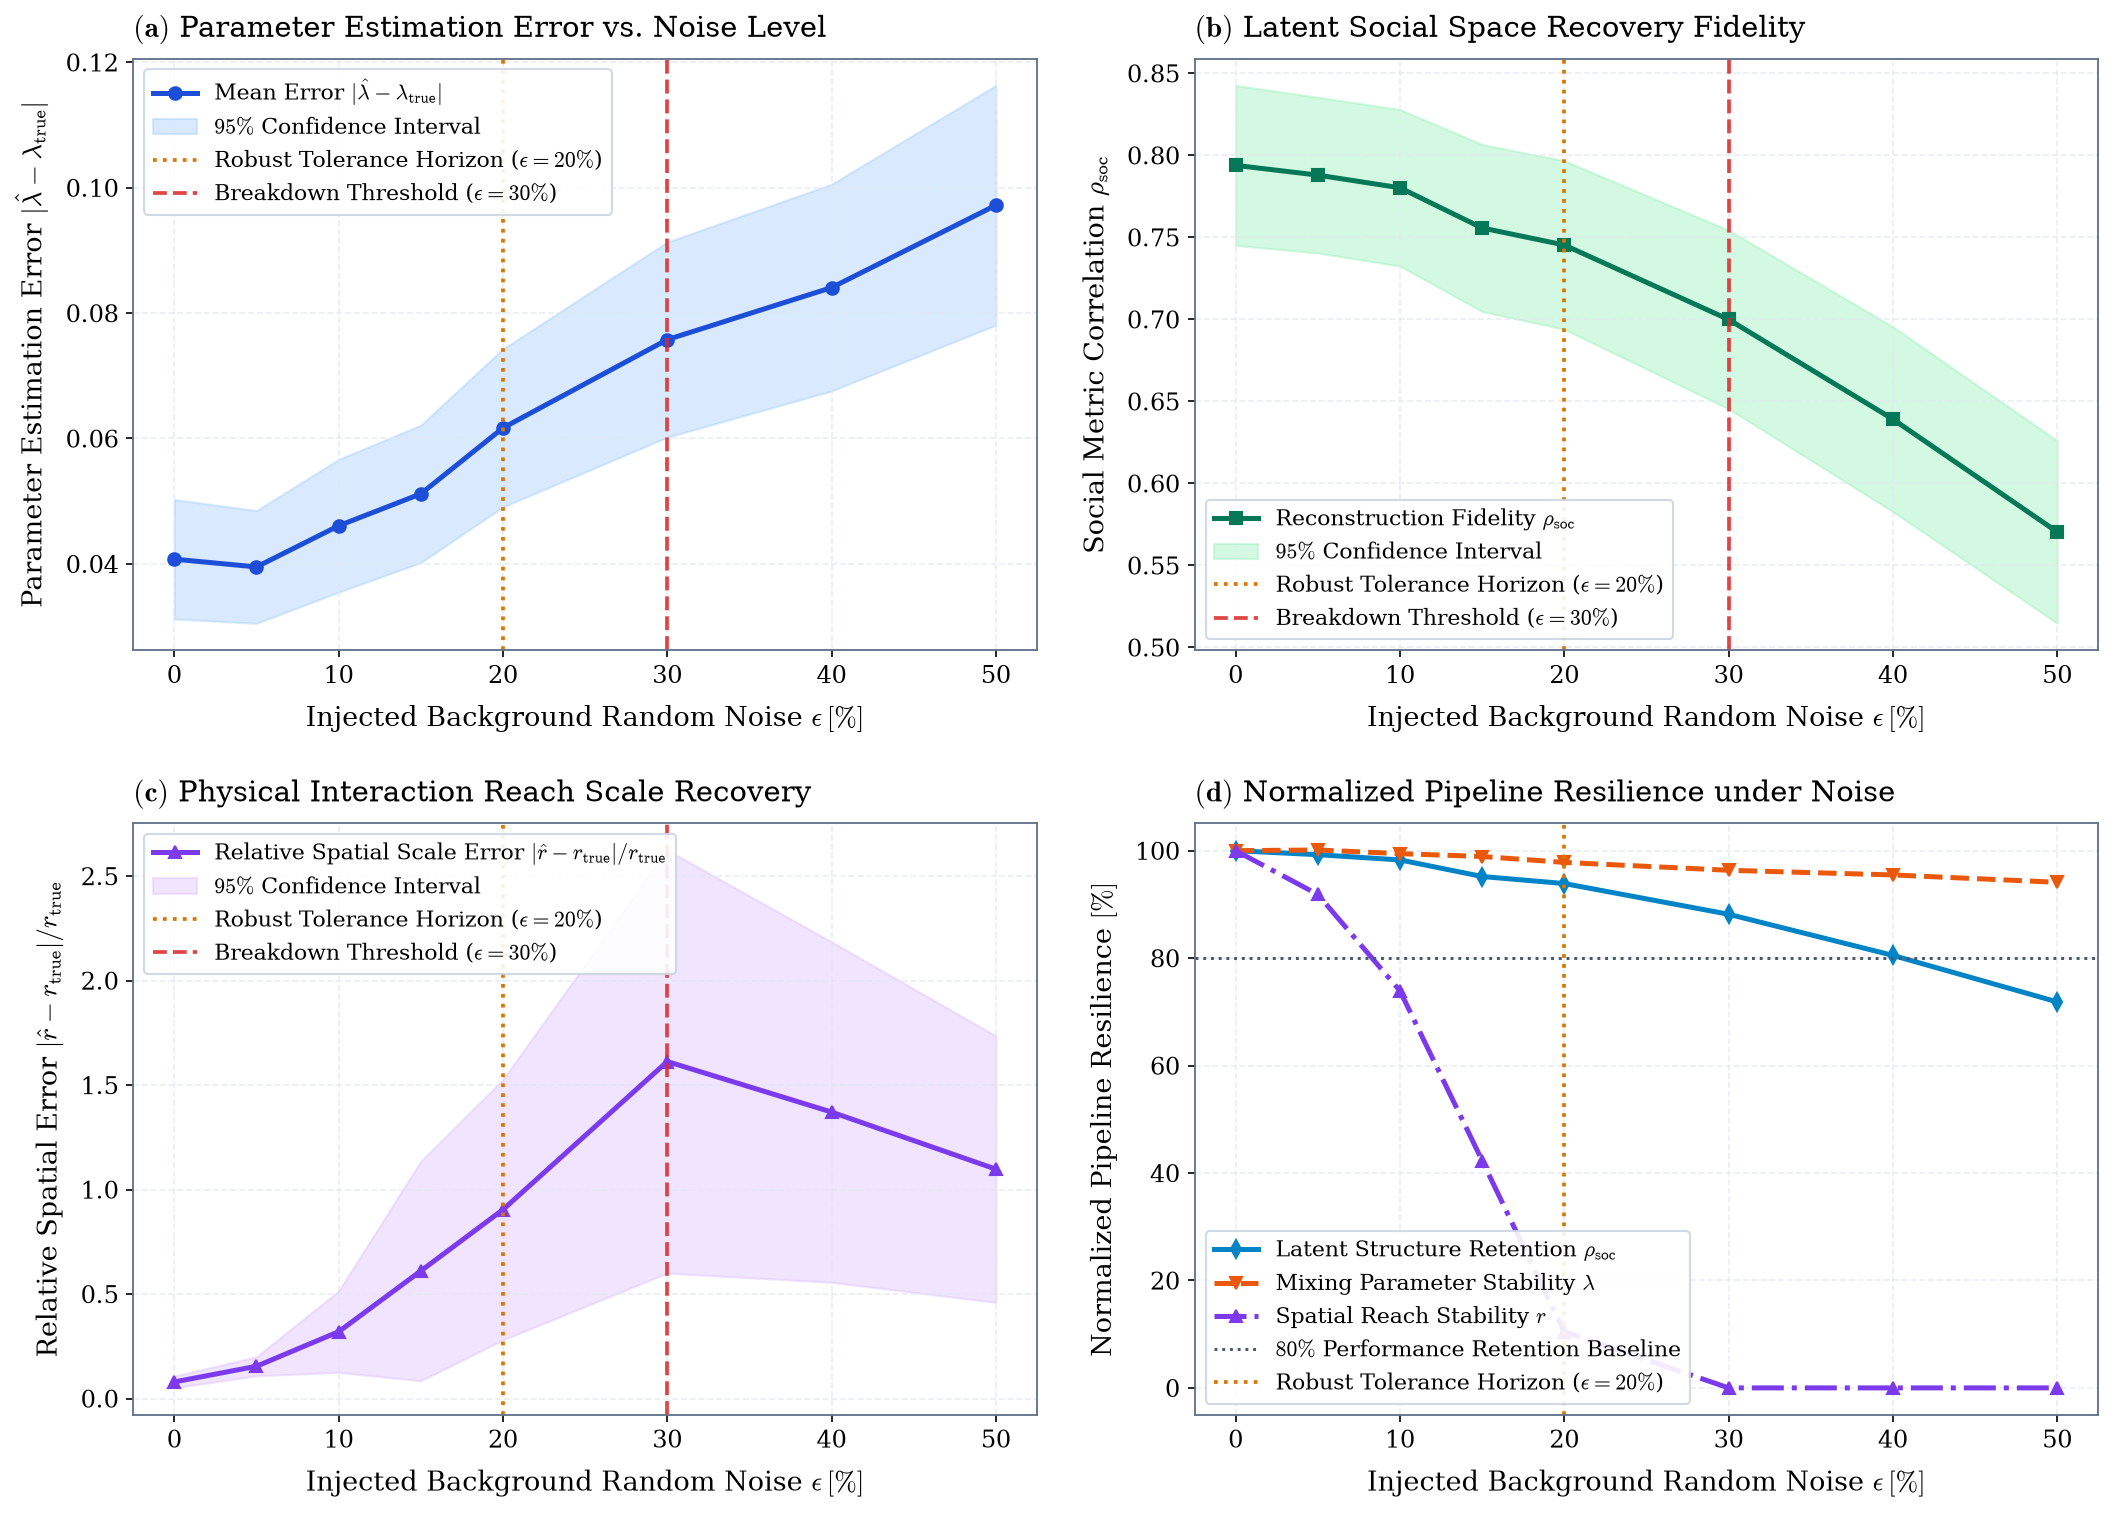


--- Summary Stress Test Table ---


epsilon   err_lam             rho_soc           err_r_rel          
               mean       std      mean       std      mean       std
0    0.00  0.040753  0.048575  0.793877  0.248693  0.079334  0.145416
1    0.05  0.039513  0.045875  0.787927  0.242285  0.154389  0.231852
2    0.10  0.046078  0.054043  0.780201  0.243529  0.319677  0.993147
3    0.15  0.051173  0.055945  0.755706  0.259833  0.610425  2.681566
4    0.20  0.061684  0.064306  0.745308  0.261896  0.903740  3.181052
5    0.30  0.075773  0.079412  0.699911  0.277985  1.612551  5.165297
6    0.40  0.084073  0.084132  0.639123  0.287519  1.370713  4.156591
7    0.50  0.097209  0.097517  0.570392  0.284106  1.097641  3.253686

In [29]:
# ======================================================================
# STRESS TEST: TOPOLOGICAL EPSILON-NOISE INJECTION (PARALLELIZED)
# ======================================================================

import os
# Disabilita l'oversubscription di thread interni per i processi worker
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# --- 1. Scrittura modulo worker isolato (Compatibilità Python 3.14+ forkserver/spawn) ---
worker_code = '''import torch
import numpy as np
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr

# Limita PyTorch a 1 thread per processo worker
torch.set_num_threads(1)

def _eps_noise_worker(task):
    net_idx, eps, seed_poisson, net_item, ETA_ADAM, T_ADAM, T_LBFGS = task
    
    N = net_item["N"]
    D_phys = net_item["D_phys"]
    W_clean = net_item["W_pred_clean"]
    iu = net_item["iu"]
    ju = net_item["ju"]
    eye_mask = net_item["eye_mask"]
    
    # Generazione rumore e realizzazione stocastica di Poisson
    rng = np.random.RandomState(seed_poisson)
    W_noise = np.ones((N, N), dtype=np.float32) / (N - 1)
    np.fill_diagonal(W_noise, 0.0)
    W_pred_noisy = (1.0 - eps) * W_clean + eps * W_noise
    
    rate = N * W_pred_noisy[iu, ju]
    w_obs_u = rng.poisson(rate).astype(np.float32)
    
    W_obs = np.zeros((N, N), dtype=np.float32)
    W_obs[iu, ju] = w_obs_u
    W_obs[ju, iu] = w_obs_u
    
    c_target = float(W_obs.sum(axis=1).mean())
    r0 = float(2.0 * D_phys.min(axis=1).mean())
    log_r0 = float(np.log(r0))
    
    # Inizializzazione SVD sul residuo
    K_sp0 = np.exp(-D_phys / r0)
    np.fill_diagonal(K_sp0, 0.0)
    s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
    W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
    R_init = np.maximum(0.0, W_obs - W_sp0)
    U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
    S_init = U[:, :2] * np.sqrt(sv[:2])
    S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0
    
    # Allocazione tensori PyTorch locali
    D_phys_t   = torch.from_numpy(D_phys).float()
    W_obs_u_t  = torch.from_numpy(w_obs_u).float()
    iu_t       = torch.from_numpy(iu).long()
    ju_t       = torch.from_numpy(ju).long()
    eye_mask_t = torch.from_numpy(eye_mask).float()
    
    logit_lam = torch.tensor(0.0, requires_grad=True)
    log_r     = torch.tensor(log_r0, requires_grad=True)
    S_param   = torch.from_numpy(S_init.astype(np.float32)).requires_grad_(True)
    
    # Fase A: Adam Warmup
    adam_opt = torch.optim.Adam([
        {"params": [logit_lam], "lr": ETA_ADAM * 2.0},
        {"params": [log_r],     "lr": ETA_ADAM},
        {"params": [S_param],   "lr": ETA_ADAM * 5.0}
    ])
    
    for _ in range(T_ADAM):
        adam_opt.zero_grad(set_to_none=True)
        lam = torch.sigmoid(logit_lam)
        r = torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0))
        
        K_sp = torch.exp(-D_phys_t / r) * eye_mask_t
        D_soc = torch.cdist(S_param, S_param)
        K_soc = torch.exp(-D_soc) * eye_mask_t
        
        W_raw_t = (1.0 - lam) * K_sp + lam * K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred_t = 0.5 * c_target * (W_raw_t / rs + W_raw_t / rs.t())
        
        wu = W_pred_t[iu_t, ju_t]
        loss = (wu - W_obs_u_t * torch.log(wu + 1e-12)).sum() + 0.5 * ((log_r - log_r0) / 2.0)**2
        loss.backward()
        adam_opt.step()
        
    # Fase B: L-BFGS Refinement
    lbfgs = torch.optim.LBFGS(
        [logit_lam, log_r, S_param],
        lr=0.5,
        max_iter=T_LBFGS,
        history_size=10,
        line_search_fn="strong_wolfe"
    )
    
    def closure():
        lbfgs.zero_grad(set_to_none=True)
        lam = torch.sigmoid(logit_lam)
        r = torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0))
        
        K_sp = torch.exp(-D_phys_t / r) * eye_mask_t
        D_soc = torch.cdist(S_param, S_param)
        K_soc = torch.exp(-D_soc) * eye_mask_t
        
        W_raw_t = (1.0 - lam) * K_sp + lam * K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred_t = 0.5 * c_target * (W_raw_t / rs + W_raw_t / rs.t())
        
        wu = W_pred_t[iu_t, ju_t]
        loss = (wu - W_obs_u_t * torch.log(wu + 1e-12)).sum() + 0.5 * ((log_r - log_r0) / 2.0)**2
        loss.backward()
        return loss
        
    try:
        lbfgs.step(closure)
        lam_hat = float(torch.sigmoid(logit_lam).item())
        r_hat   = float(torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0)).item())
        err_lam = abs(lam_hat - net_item["lambda_true"])
        err_r_rel = abs(r_hat - net_item["r_true"]) / net_item["r_true"]
        
        S_hat = S_param.detach().numpy()
        D_soc_hat = cdist(S_hat, S_hat)[iu, ju]
        D_soc_gt  = net_item["D_soc_flat"]
        rho_soc, _ = pearsonr(D_soc_hat, D_soc_gt)
        if np.isnan(rho_soc):
            rho_soc = 0.0
    except Exception:
        err_lam = 1.0
        err_r_rel = 10.0
        rho_soc = 0.0
        
    return {
        "network_idx": net_idx,
        "epsilon": eps,
        "err_lam": err_lam,
        "err_r_rel": err_r_rel,
        "rho_soc": rho_soc
    }
'''

with open("_eps_worker.py", "w") as f:
    f.write(worker_code)

from _eps_worker import _eps_noise_worker

import time, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from concurrent.futures import ProcessPoolExecutor
from IPython.display import display

# Output directory resolution
output_dir = "Robustness_tests" if os.path.basename(os.getcwd()) != "Robustness_tests" else "."
os.makedirs(output_dir, exist_ok=True)

# Typography & High-Quality Plot Settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 13.0,
    "axes.titlesize": 14.0,
    "xtick.labelsize": 11.5,
    "ytick.labelsize": 11.5,
    "legend.fontsize": 10.5,
    "axes.edgecolor": "#64748b",
    "axes.linewidth": 0.9,
    "grid.color": "#e2e8f0",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "figure.dpi": 150
})

np.random.seed(42)

# --- Synthetic Network Generator ---
def sample_synthetic_network(N=None, lambda_true=None, r_true=None, sigma_true=None, d_s=2, seed=None):
    if seed is not None:
        np.random.seed(seed)
    if N is None:
        N = int(np.random.randint(120, 250))
    if lambda_true is None:
        lambda_true = float(np.random.uniform(0.10, 0.90))
    if r_true is None:
        r_true = float(np.exp(np.random.uniform(np.log(0.04), np.log(0.40))))
    if sigma_true is None:
        sigma_true = float(np.exp(np.random.uniform(np.log(0.04), np.log(0.40))))
    
    X_phys = np.random.uniform(0.0, 1.0, size=(N, 2))
    
    K = int(np.random.randint(2, 9))
    gmm_means = np.random.uniform(0.1, 0.9, size=(K, d_s))
    gmm_covs  = [np.diag(np.random.uniform(0.01, 0.05, size=d_s)) for _ in range(K)]
    weights   = np.random.dirichlet(np.ones(K))
    comp_choices = np.random.choice(K, size=N, p=weights)
    
    S_true = np.zeros((N, d_s))
    for k in range(K):
        idx_k = np.where(comp_choices == k)[0]
        if len(idx_k) > 0:
            S_true[idx_k] = np.random.multivariate_normal(gmm_means[k], gmm_covs[k], size=len(idx_k))
    S_min, S_max = S_true.min(axis=0), S_true.max(axis=0)
    S_true = (S_true - S_min) / (S_max - S_min + 1e-9)
    
    D_phys = cdist(X_phys, X_phys); np.fill_diagonal(D_phys, 1e9)
    D_soc  = cdist(S_true, S_true); np.fill_diagonal(D_soc, 1e9)
    
    K_sp  = np.exp(-D_phys / r_true);     np.fill_diagonal(K_sp, 0.0)
    K_soc = np.exp(-D_soc / sigma_true);  np.fill_diagonal(K_soc, 0.0)
    
    W_raw = (1.0 - lambda_true) * K_sp + lambda_true * K_soc
    row_sum = W_raw.sum(axis=1, keepdims=True) + 1e-12
    W_pred_clean = 0.5 * (W_raw / row_sum + W_raw / row_sum.T)
    
    return {
        "N": N, "lambda_true": lambda_true, "r_true": r_true, "sigma_true": sigma_true,
        "D_phys": D_phys, "D_soc": D_soc, "S_true": S_true, "W_pred_clean": W_pred_clean
    }

# --- Sweep Configuration ---
epsilons = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
N_BENCHMARK_NETWORKS = 100
ETA_ADAM = 0.04
T_ADAM = 50
T_LBFGS = 40

tag = f"Nnets{N_BENCHMARK_NETWORKS}_Tadam{T_ADAM}_Tlbfgs{T_LBFGS}"

print(f"Precomputing {N_BENCHMARK_NETWORKS} base synthetic networks...")
ensemble_precomputed = []
for i in range(N_BENCHMARK_NETWORKS):
    net = sample_synthetic_network(seed=700 + i)
    N = net["N"]
    iu, ju = np.triu_indices(N, k=1)
    
    ensemble_precomputed.append({
        "N": N,
        "lambda_true": net["lambda_true"],
        "r_true": net["r_true"],
        "D_phys": net["D_phys"].astype(np.float32),
        "W_pred_clean": net["W_pred_clean"].astype(np.float32),
        "iu": iu.astype(np.int64),
        "ju": ju.astype(np.int64),
        "eye_mask": (1.0 - np.eye(N)).astype(np.float32),
        "D_soc_flat": net["D_soc"][iu, ju].astype(np.float64)
    })

num_workers = os.cpu_count() or 4
print(f"Launching Topological Epsilon-Noise Stress Test across {len(epsilons)} noise levels on {num_workers} CPU workers...")
print(f"{'Noise (ε)':<12} | {'Mean |Δλ|':<12} | {'Mean ρ_soc':<12} | {'Mean Δr/r':<12} | {'Level Time':<11} | {'Elapsed':<8}")
print("-" * 78)

t_start = time.time()
records_eps = []

with ProcessPoolExecutor(max_workers=num_workers) as executor:
    for eps in epsilons:
        t_eps = time.time()
        
        eps_tasks = [
            (idx, eps, 70000 + idx * 100 + int(eps * 1000), net_item, ETA_ADAM, T_ADAM, T_LBFGS)
            for idx, net_item in enumerate(ensemble_precomputed)
        ]
        eps_results = list(executor.map(_eps_noise_worker, eps_tasks, chunksize=8))
        records_eps.extend(eps_results)
        
        mean_err_lam = np.mean([r["err_lam"] for r in eps_results])
        mean_rho = np.mean([r["rho_soc"] for r in eps_results])
        mean_err_r = np.mean([r["err_r_rel"] for r in eps_results])
        t_level = time.time() - t_eps
        t_elapsed = time.time() - t_start
        
        print(f"ε = {eps:<8.2f} | {mean_err_lam:<12.4f} | {mean_rho:<12.4f} | {mean_err_r:<12.4f} | {t_level:<10.2f}s | {t_elapsed:<7.1f}s")

print("-" * 78)
print(f"Stress test completed in {time.time() - t_start:.2f}s.")

# --- Save CSVs & Integrity Verification ---
df_raw = pd.DataFrame(records_eps)
raw_csv_path = os.path.join(output_dir, f"epsilon_noise_raw_{tag}.csv")
df_raw.to_csv(raw_csv_path, index=False)

df_summary = df_raw.groupby("epsilon").agg({
    "err_lam": ["mean", "std"],
    "rho_soc": ["mean", "std"],
    "err_r_rel": ["mean", "std"]
}).reset_index()

summary_csv_path = os.path.join(output_dir, f"epsilon_noise_summary_{tag}.csv")
df_summary.to_csv(summary_csv_path, index=False)

print("\n--- CSV Export Verification ---")
for p in [raw_csv_path, summary_csv_path]:
    if os.path.isfile(p):
        size_kb = os.path.getsize(p) / 1024
        print(f"  [OK] Saved: {os.path.basename(p):<55} ({size_kb:.1f} KB)")
    else:
        raise FileNotFoundError(f"Export check failed for {p}")

# --- Publication 4-Panel Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14.5, 10.5))
eps_vals = df_summary["epsilon"].values * 100.0

# (a) Parameter Estimation Error
ax1 = axes[0, 0]
m_lam = df_summary["err_lam"]["mean"].values
s_lam = df_summary["err_lam"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)
ax1.plot(eps_vals, m_lam, marker="o", color="#1d4ed8", lw=2.4, markersize=6, label=r"Mean Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$")
ax1.fill_between(eps_vals, np.maximum(0, m_lam - 1.96 * s_lam), m_lam + 1.96 * s_lam, color="#93c5fd", alpha=0.35, label=r"$95\%$ Confidence Interval")
ax1.axvline(20, color="#d97706", ls=":", lw=1.8, label=r"Robust Tolerance Horizon ($\epsilon = 20\%$)")
ax1.axvline(30, color="#dc2626", ls="--", lw=1.8, alpha=0.85, label=r"Breakdown Threshold ($\epsilon = 30\%$)")
ax1.set_xlabel(r"Injected Background Random Noise $\epsilon \, [\%]$", labelpad=8)
ax1.set_ylabel(r"Parameter Estimation Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$", labelpad=8)
ax1.set_title(r"$\mathbf{(a)}$ Parameter Estimation Error vs. Noise Level", loc="left", pad=10)
ax1.grid(True)
ax1.legend(loc="upper left", framealpha=0.9, edgecolor="#cbd5e1")

# (b) Latent Social Metric Fidelity
ax2 = axes[0, 1]
m_rho = df_summary["rho_soc"]["mean"].values
s_rho = df_summary["rho_soc"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)
ax2.plot(eps_vals, m_rho, marker="s", color="#047857", lw=2.4, markersize=6, label=r"Reconstruction Fidelity $\rho_{\mathrm{soc}}$")
ax2.fill_between(eps_vals, np.maximum(0, m_rho - 1.96 * s_rho), np.minimum(1.0, m_rho + 1.96 * s_rho), color="#86efac", alpha=0.35, label=r"$95\%$ Confidence Interval")
ax2.axvline(20, color="#d97706", ls=":", lw=1.8, label=r"Robust Tolerance Horizon ($\epsilon = 20\%$)")
ax2.axvline(30, color="#dc2626", ls="--", lw=1.8, alpha=0.85, label=r"Breakdown Threshold ($\epsilon = 30\%$)")
ax2.set_xlabel(r"Injected Background Random Noise $\epsilon \, [\%]$", labelpad=8)
ax2.set_ylabel(r"Social Metric Correlation $\rho_{\mathrm{soc}}$", labelpad=8)
ax2.set_title(r"$\mathbf{(b)}$ Latent Social Space Recovery Fidelity", loc="left", pad=10)
ax2.grid(True)
ax2.legend(loc="lower left", framealpha=0.9, edgecolor="#cbd5e1")

# (c) Physical Interaction Reach Scale Recovery
ax3 = axes[1, 0]
m_r = df_summary["err_r_rel"]["mean"].values
s_r = df_summary["err_r_rel"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)
ax3.plot(eps_vals, m_r, marker="^", color="#7c3aed", lw=2.4, markersize=6, label=r"Relative Spatial Scale Error $|\hat{r} - r_{\mathrm{true}}| / r_{\mathrm{true}}$")
ax3.fill_between(eps_vals, np.maximum(0, m_r - 1.96 * s_r), m_r + 1.96 * s_r, color="#d8b4fe", alpha=0.35, label=r"$95\%$ Confidence Interval")
ax3.axvline(20, color="#d97706", ls=":", lw=1.8, label=r"Robust Tolerance Horizon ($\epsilon = 20\%$)")
ax3.axvline(30, color="#dc2626", ls="--", lw=1.8, alpha=0.85, label=r"Breakdown Threshold ($\epsilon = 30\%$)")
ax3.set_xlabel(r"Injected Background Random Noise $\epsilon \, [\%]$", labelpad=8)
ax3.set_ylabel(r"Relative Spatial Error $|\hat{r} - r_{\mathrm{true}}| / r_{\mathrm{true}}$", labelpad=8)
ax3.set_title(r"$\mathbf{(c)}$ Physical Interaction Reach Scale Recovery", loc="left", pad=10)
ax3.grid(True)
ax3.legend(loc="upper left", framealpha=0.9, edgecolor="#cbd5e1")

# (d) Normalized Pipeline Resilience Curve
ax4 = axes[1, 1]
norm_fidelity = (m_rho / m_rho[0]) * 100.0
norm_param_stability = np.maximum(0.0, (1.0 - (m_lam - m_lam[0]) / (1.0 - m_lam[0]))) * 100.0
norm_spatial_stability = np.maximum(0.0, (1.0 - (m_r - m_r[0]) / (1.0 - m_r[0]))) * 100.0

ax4.plot(eps_vals, norm_fidelity, marker="d", color="#0284c7", lw=2.4, markersize=6, label=r"Latent Structure Retention $\rho_{\mathrm{soc}}$")
ax4.plot(eps_vals, norm_param_stability, marker="v", color="#ea580c", lw=2.4, ls="--", markersize=6, label=r"Mixing Parameter Stability $\lambda$")
ax4.plot(eps_vals, norm_spatial_stability, marker="^", color="#7c3aed", lw=2.4, ls="-.", markersize=6, label=r"Spatial Reach Stability $r$")
ax4.axhline(80, color="#475569", ls=":", lw=1.4, label=r"$80\%$ Performance Retention Baseline")
ax4.axvline(20, color="#d97706", ls=":", lw=1.8, label=r"Robust Tolerance Horizon ($\epsilon = 20\%$)")

ax4.set_xlabel(r"Injected Background Random Noise $\epsilon \, [\%]$", labelpad=8)
ax4.set_ylabel(r"Normalized Pipeline Resilience $[\%]$", labelpad=8)
ax4.set_title(r"$\mathbf{(d)}$ Normalized Pipeline Resilience under Noise", loc="left", pad=10)
ax4.grid(True)
ax4.legend(loc="lower left", framealpha=0.9, edgecolor="#cbd5e1")

for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_color("#64748b")
        spine.set_linewidth(0.9)

plt.tight_layout(pad=2.2)

# Save publication figures
pdf_path = os.path.join(output_dir, f"epsilon_noise_plot_{tag}.pdf")
png_path = os.path.join(output_dir, f"epsilon_noise_plot_{tag}.png")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")

print("\n--- Figure Export Verification ---")
for fpath in [pdf_path, png_path]:
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  [OK] Saved: {os.path.basename(fpath):<55} ({size_kb:.1f} KB)")
    else:
        raise FileNotFoundError(f"Export check failed for {fpath}")

plt.show()

print("\n--- Summary Stress Test Table ---")
display(df_summary)


--- Figure Export Verification ---
  [OK] Saved: epsilon_noise_resilience_Nnets100_Tadam50_Tlbfgs40.pdf  (24.8 KB)
  [OK] Saved: epsilon_noise_resilience_Nnets100_Tadam50_Tlbfgs40.png  (207.2 KB)


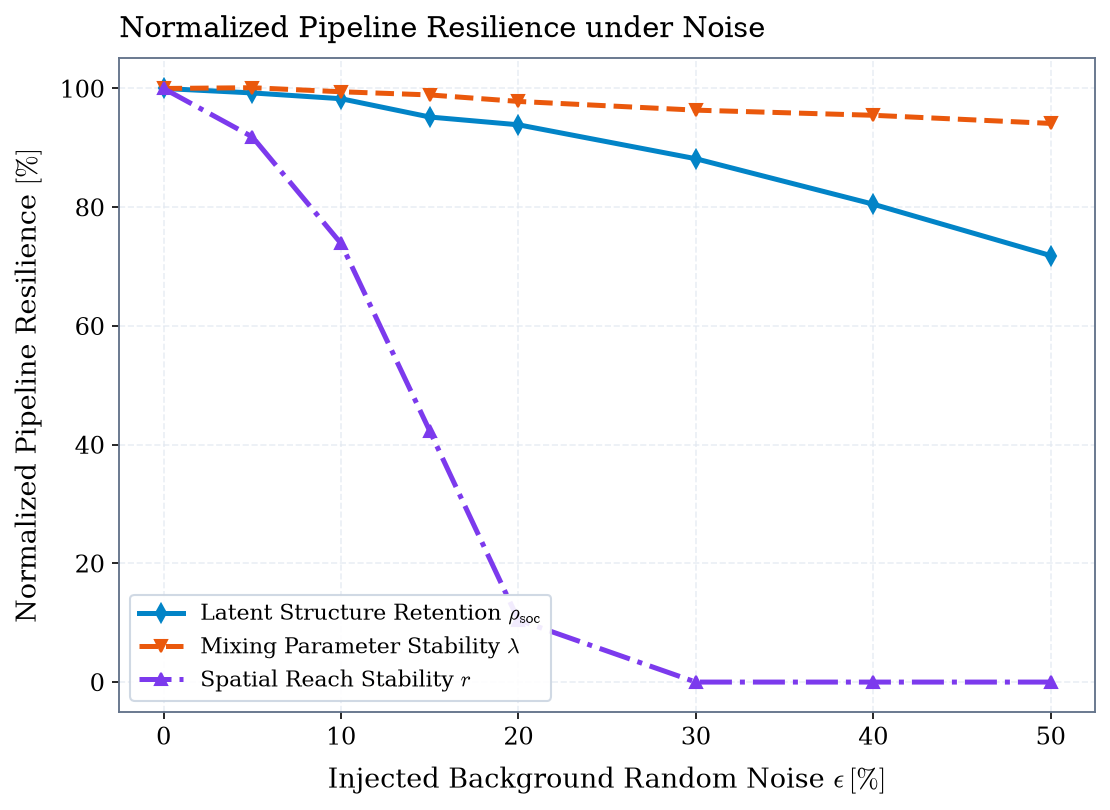

In [30]:
# --- Publication Single-Panel Visualization (Resilience Only) ---
fig, ax = plt.subplots(figsize=(7.5, 5.5))
eps_vals = df_summary["epsilon"].values * 100.0

m_lam = df_summary["err_lam"]["mean"].values
m_rho = df_summary["rho_soc"]["mean"].values
m_r   = df_summary["err_r_rel"]["mean"].values

norm_fidelity = (m_rho / m_rho[0]) * 100.0
norm_param_stability = np.maximum(0.0, (1.0 - (m_lam - m_lam[0]) / (1.0 - m_lam[0]))) * 100.0
norm_spatial_stability = np.maximum(0.0, (1.0 - (m_r - m_r[0]) / (1.0 - m_r[0]))) * 100.0

ax.plot(eps_vals, norm_fidelity, marker="d", color="#0284c7", lw=2.4, markersize=6, label=r"Latent Structure Retention $\rho_{\mathrm{soc}}$")
ax.plot(eps_vals, norm_param_stability, marker="v", color="#ea580c", lw=2.4, ls="--", markersize=6, label=r"Mixing Parameter Stability $\lambda$")
ax.plot(eps_vals, norm_spatial_stability, marker="^", color="#7c3aed", lw=2.4, ls="-.", markersize=6, label=r"Spatial Reach Stability $r$")

ax.set_xlabel(r"Injected Background Random Noise $\epsilon \, [\%]$", labelpad=8)
ax.set_ylabel(r"Normalized Pipeline Resilience $[\%]$", labelpad=8)
ax.set_title(r"Normalized Pipeline Resilience under Noise", loc="left", pad=10)
ax.grid(True)
ax.legend(loc="lower left", framealpha=0.9, edgecolor="#cbd5e1")

for spine in ax.spines.values():
    spine.set_color("#64748b")
    spine.set_linewidth(0.9)

plt.tight_layout()

# Save publication figures
pdf_path = os.path.join(output_dir, f"epsilon_noise_resilience_{tag}.pdf")
png_path = os.path.join(output_dir, f"epsilon_noise_resilience_{tag}.png")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")

print("\n--- Figure Export Verification ---")
for fpath in [pdf_path, png_path]:
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  [OK] Saved: {os.path.basename(fpath):<55} ({size_kb:.1f} KB)")
    else:
        raise FileNotFoundError(f"Export check failed for {fpath}")

plt.show()

<h3>Exploration phase duration</h3>

Executing Warmup Duration Sweep T_Adam [Nnets30_eta0.01_Tlbfgs40]...
  → T_Adam =  10 steps | |Δλ| = 0.1141 | ρ_soc = 0.6805 (14.75s)
  → T_Adam =  20 steps | |Δλ| = 0.1135 | ρ_soc = 0.6976 (16.61s)
  → T_Adam =  30 steps | |Δλ| = 0.1207 | ρ_soc = 0.7243 (20.02s)
  → T_Adam =  40 steps | |Δλ| = 0.0961 | ρ_soc = 0.7482 (19.11s)
  → T_Adam =  50 steps | |Δλ| = 0.0662 | ρ_soc = 0.7661 (17.69s)
  → T_Adam =  60 steps | |Δλ| = 0.0667 | ρ_soc = 0.7776 (17.73s)
  → T_Adam =  80 steps | |Δλ| = 0.0613 | ρ_soc = 0.7900 (27.99s)
  → T_Adam = 100 steps | |Δλ| = 0.0618 | ρ_soc = 0.7951 (25.39s)
  → T_Adam = 120 steps | |Δλ| = 0.0605 | ρ_soc = 0.8010 (33.90s)

Calculations saved successfully:
  • Raw: ./t_adam_sensitivity_raw_Nnets30_eta0.01_Tlbfgs40.csv
  • Summary: ./t_adam_sensitivity_summary_Nnets30_eta0.01_Tlbfgs40.csv
Figures exported:
  • PDF: ./t_adam_sensitivity_plot_Nnets30_eta0.01_Tlbfgs40.pdf
  • PNG: ./t_adam_sensitivity_plot_Nnets30_eta0.01_Tlbfgs40.png


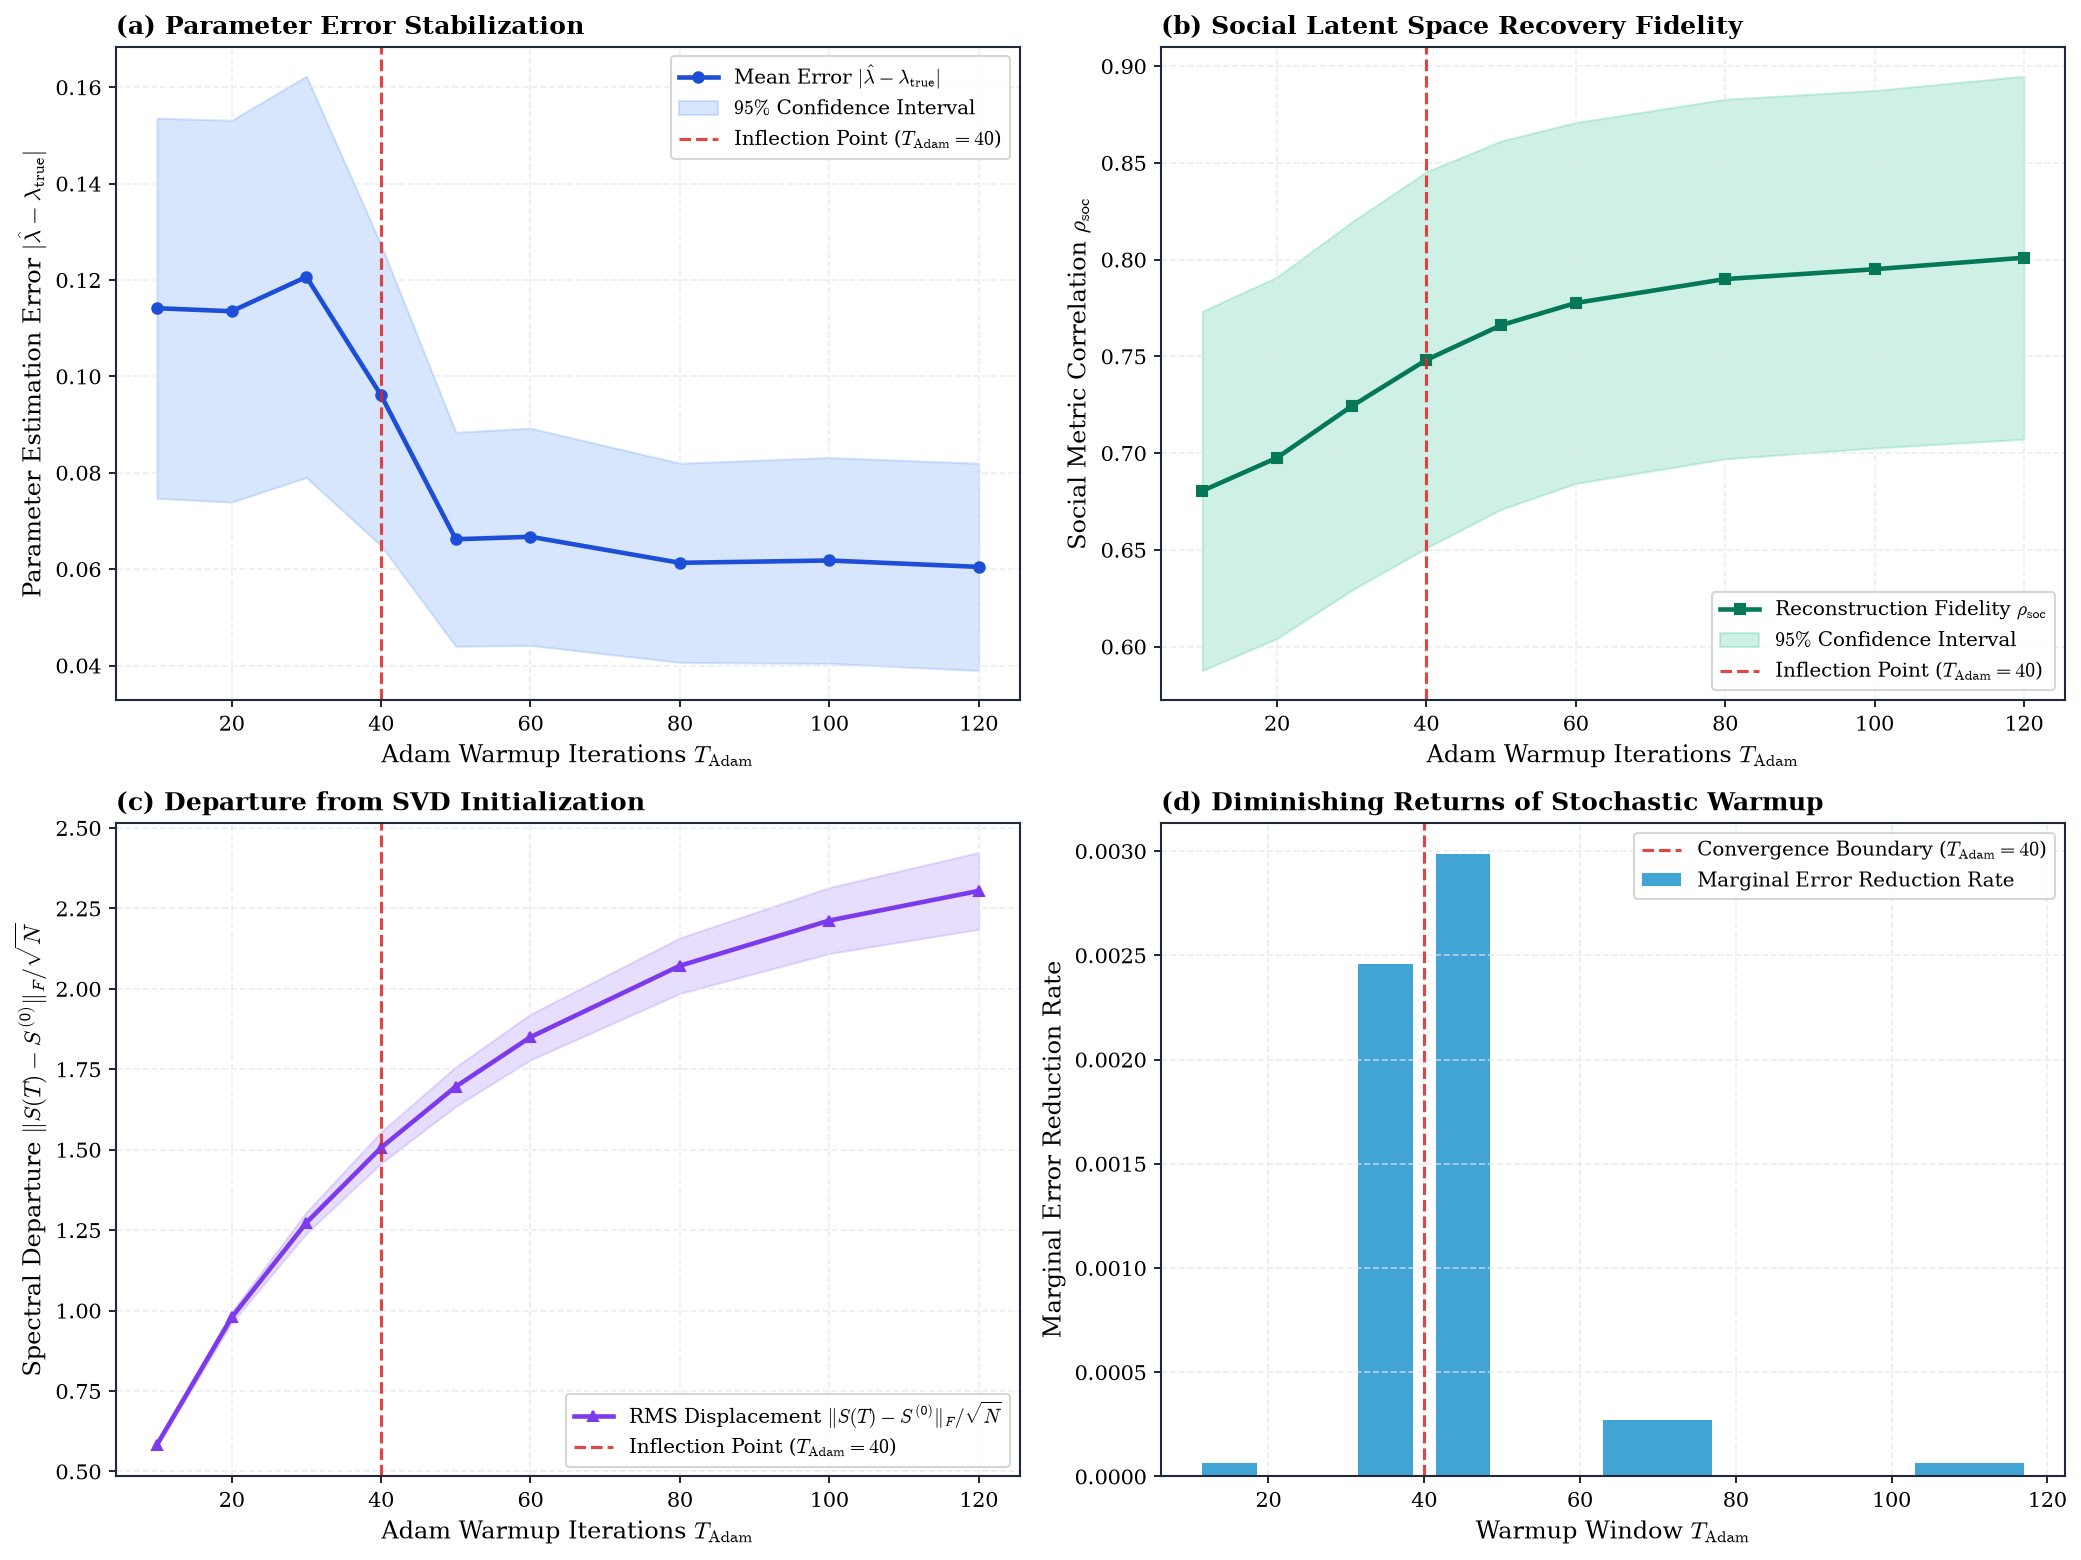

t_adam   err_lam             rho_soc           spectral_disp          
              mean       std      mean       std          mean       std
0     10  0.114146  0.110227  0.680476  0.259427      0.583287  0.018084
1     20  0.113521  0.110694  0.697578  0.260998      0.979088  0.049163
2     30  0.120652  0.116358  0.724253  0.265883      1.273371  0.092275
3     40  0.096071  0.087205  0.748170  0.271709      1.506588  0.136170
4     50  0.066203  0.062067  0.766119  0.265983      1.696278  0.171482
5     60  0.066720  0.062974  0.777621  0.260606      1.850216  0.198435
6     80  0.061318  0.057752  0.789968  0.259675      2.071916  0.240953
7    100  0.061796  0.059704  0.795051  0.258192      2.212416  0.286338
8    120  0.060469  0.060098  0.801007  0.262160      2.304493  0.333820

In [10]:
# ======================================================================
# EXPERIMENT 2: EXPLORATION PHASE DURATION (T_Adam in [10, 120])
# ======================================================================

import os, time, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
from IPython.display import display

output_dir = "Robustness_tests" if os.path.basename(os.getcwd()) != "Robustness_tests" else "."
os.makedirs(output_dir, exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 11.5,
    "axes.titlesize": 12.0,
    "xtick.labelsize": 10.0,
    "ytick.labelsize": 10.0,
    "legend.fontsize": 9.5,
    "axes.edgecolor": "#1e293b",
    "axes.linewidth": 1.0,
    "grid.color": "#e2e8f0",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "figure.dpi": 150
})

device = torch.device("cpu")
torch.manual_seed(42); np.random.seed(42)

# --- Synthetic Network Generator ---
def sample_synthetic_network(N=None, lambda_true=None, r_true=None, sigma_true=None, d_s=2):
    if N is None:
        N = int(np.random.randint(100, 301))
    if lambda_true is None:
        lambda_true = float(np.random.uniform(0.05, 0.95))
    if r_true is None:
        r_true = float(np.exp(np.random.uniform(np.log(0.03), np.log(0.50))))
    if sigma_true is None:
        sigma_true = float(np.exp(np.random.uniform(np.log(0.03), np.log(0.50))))
    
    X_phys = np.random.uniform(0.0, 1.0, size=(N, 2))
    
    K = int(np.random.randint(2, 9))
    gmm_means = np.random.uniform(0.1, 0.9, size=(K, d_s))
    gmm_covs  = [np.diag(np.random.uniform(0.01, 0.05, size=d_s)) for _ in range(K)]
    weights   = np.random.dirichlet(np.ones(K))
    comp_choices = np.random.choice(K, size=N, p=weights)
    
    S_true = np.zeros((N, d_s))
    for k in range(K):
        idx_k = np.where(comp_choices == k)[0]
        if len(idx_k) > 0:
            S_true[idx_k] = np.random.multivariate_normal(gmm_means[k], gmm_covs[k], size=len(idx_k))
    S_min, S_max = S_true.min(axis=0), S_true.max(axis=0)
    S_true = (S_true - S_min) / (S_max - S_min + 1e-9)
    
    D_phys = cdist(X_phys, X_phys); np.fill_diagonal(D_phys, 1e9)
    D_soc  = cdist(S_true, S_true); np.fill_diagonal(D_soc, 1e9)
    
    K_sp  = np.exp(-D_phys / r_true);     np.fill_diagonal(K_sp, 0.0)
    K_soc = np.exp(-D_soc / sigma_true);  np.fill_diagonal(K_soc, 0.0)
    
    W_raw = (1.0 - lambda_true) * K_sp + lambda_true * K_soc
    row_sum = W_raw.sum(axis=1, keepdims=True) + 1e-12
    W_pred = 0.5 * (W_raw / row_sum + W_raw / row_sum.T)
    
    iu, ju = np.triu_indices(N, k=1)
    rate = N * W_pred[iu, ju]
    w_obs_u = np.random.poisson(rate).astype(float)
    
    W_obs = np.zeros((N, N))
    W_obs[iu, ju] = w_obs_u
    W_obs[ju, iu] = w_obs_u
    
    return {
        "N": N, "lambda_true": lambda_true, "r_true": r_true, "sigma_true": sigma_true,
        "D_phys": D_phys, "D_soc": D_soc, "S_true": S_true, "W_obs": W_obs
    }

# --- Sweep Parameters ---
N_BENCHMARK_NETWORKS = 30
t_adam_list = [10, 20, 30, 40, 50, 60, 80, 100, 120]
ETA_ADAM = 1e-2
T_LBFGS = 40

tag = f"Nnets{N_BENCHMARK_NETWORKS}_eta{ETA_ADAM}_Tlbfgs{T_LBFGS}"
print(f"Executing Warmup Duration Sweep T_Adam [{tag}]...")
t_start = time.time()
records_t_adam = []

ensemble = [sample_synthetic_network() for _ in range(N_BENCHMARK_NETWORKS)]

for t_adam in t_adam_list:
    t_step = time.time()
    for net_idx, net in enumerate(ensemble):
        N = net["N"]; W = net["W_obs"]; D_phys = net["D_phys"]
        iu, ju = np.triu_indices(N, k=1)
        c_target = float(W.sum(axis=1).mean())
        r0 = float(2.0 * D_phys.min(axis=1).mean()); log_r0 = float(np.log(r0))
        
        D_phys_t = torch.tensor(D_phys, dtype=torch.float32, device=device)
        W_obs_u  = torch.tensor(W[iu, ju], dtype=torch.float32, device=device)
        iu_t, ju_t = torch.tensor(iu, dtype=torch.long, device=device), torch.tensor(ju, dtype=torch.long, device=device)
        eye_mask = 1.0 - torch.eye(N, device=device)
        
        # SVD Init
        K_sp0 = np.exp(-D_phys / r0); np.fill_diagonal(K_sp0, 0.0)
        s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
        W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
        R_init = np.maximum(0.0, W - W_sp0)
        U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
        S_init = U[:, :2] * np.sqrt(sv[:2])
        S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0
        
        logit_lam = torch.tensor(0.0, requires_grad=True, device=device)
        log_r     = torch.tensor(log_r0, requires_grad=True, device=device)
        S_param   = torch.tensor(S_init, requires_grad=True, device=device)
        
        adam_opt = torch.optim.Adam([
            {"params": [logit_lam], "lr": ETA_ADAM * 2.0},
            {"params": [log_r],     "lr": ETA_ADAM},
            {"params": [S_param],   "lr": ETA_ADAM * 5.0}
        ])
        for _ in range(t_adam):
            adam_opt.zero_grad()
            lam = torch.sigmoid(logit_lam); r = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
            K_sp = torch.exp(-D_phys_t / r) * eye_mask
            diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
            D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(N, device=device)
            K_soc = torch.exp(-D_soc / 1.0) * eye_mask
            W_raw_t = (1-lam)*K_sp + lam*K_soc
            rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
            W_pred_t = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
            wu = W_pred_t[iu_t, ju_t]
            loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
            loss.backward(); adam_opt.step()
            
        S_relaxed = S_param.detach().cpu().numpy()
        spectral_displacement = float(np.linalg.norm(S_relaxed - S_init) / np.sqrt(N))
        
        # L-BFGS Polish
        lbfgs = torch.optim.LBFGS([logit_lam, log_r, S_param], lr=0.5,
                                  max_iter=T_LBFGS, history_size=10, line_search_fn="strong_wolfe")
        def closure():
            lbfgs.zero_grad()
            lam = torch.sigmoid(logit_lam); r = torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3))
            K_sp = torch.exp(-D_phys_t / r) * eye_mask
            diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
            D_soc = torch.sqrt((diff**2).sum(-1)+1e-12) + 1e9*torch.eye(N, device=device)
            K_soc = torch.exp(-D_soc / 1.0) * eye_mask
            W_raw_t = (1-lam)*K_sp + lam*K_soc
            rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
            W_pred_t = 0.5*c_target*(W_raw_t/rs + W_raw_t/rs.t())
            wu = W_pred_t[iu_t, ju_t]
            loss = (wu - W_obs_u*torch.log(wu+1e-12)).sum() + 0.5*((log_r-log_r0)/2)**2
            loss.backward(); return loss
        
        lbfgs.step(closure)
        lam_hat = float(torch.sigmoid(logit_lam).item())
        r_hat   = float(torch.exp(torch.clamp(log_r, log_r0-3, log_r0+3)).item())
        err_lam = abs(lam_hat - net["lambda_true"])
        err_r_rel = abs(r_hat - net["r_true"]) / net["r_true"]
        
        S_hat = S_param.detach().cpu().numpy()
        D_soc_hat = cdist(S_hat, S_hat)[iu, ju]
        D_soc_gt  = net["D_soc"][iu, ju]
        rho_soc, _ = pearsonr(D_soc_hat, D_soc_gt)
        
        records_t_adam.append({
            "network_idx": net_idx, "t_adam": t_adam, "err_lam": err_lam,
            "err_r_rel": err_r_rel, "rho_soc": rho_soc, "spectral_disp": spectral_displacement
        })
    print(f"  → T_Adam = {t_adam:3d} steps | |Δλ| = {np.mean([r['err_lam'] for r in records_t_adam if r['t_adam']==t_adam]):.4f} | ρ_soc = {np.mean([r['rho_soc'] for r in records_t_adam if r['t_adam']==t_adam]):.4f} ({time.time()-t_step:.2f}s)")

# Save CSVs
df_raw = pd.DataFrame(records_t_adam)
raw_csv_path = f"{output_dir}/t_adam_sensitivity_raw_{tag}.csv"
df_raw.to_csv(raw_csv_path, index=False)

df_summary = df_raw.groupby("t_adam").agg({
    "err_lam": ["mean", "std"],
    "rho_soc": ["mean", "std"],
    "spectral_disp": ["mean", "std"]
}).reset_index()
summary_csv_path = f"{output_dir}/t_adam_sensitivity_summary_{tag}.csv"
df_summary.to_csv(summary_csv_path, index=False)
print(f"\nCalculations saved successfully:\n  • Raw: {raw_csv_path}\n  • Summary: {summary_csv_path}")

# --- Publication 4-Panel Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10.5))
t_vals = df_summary["t_adam"].values

# (a) Parameter Estimation Error
ax1 = axes[0, 0]
m_lam = df_summary["err_lam"]["mean"].values
s_lam = df_summary["err_lam"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)
ax1.plot(t_vals, m_lam, marker="o", color="#1d4ed8", lw=2.2, markersize=5, label=r"Mean Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$")
ax1.fill_between(t_vals, m_lam - 1.96*s_lam, m_lam + 1.96*s_lam, color="#3b82f6", alpha=0.20, label=r"$95\%$ Confidence Interval")
ax1.axvline(40, color="#dc2626", ls="--", lw=1.5, alpha=0.85, label=r"Inflection Point ($T_{\mathrm{Adam}} = 40$)")
ax1.set_xlabel(r"Adam Warmup Iterations $T_{\mathrm{Adam}}$")
ax1.set_ylabel(r"Parameter Estimation Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$")
ax1.set_title("(a) Parameter Error Stabilization", loc="left", fontweight="bold")
ax1.grid(True); ax1.legend(loc="upper right")

# (b) Latent Social Metric Fidelity
ax2 = axes[0, 1]
m_rho = df_summary["rho_soc"]["mean"].values
s_rho = df_summary["rho_soc"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)
ax2.plot(t_vals, m_rho, marker="s", color="#047857", lw=2.2, markersize=5, label=r"Reconstruction Fidelity $\rho_{\mathrm{soc}}$")
ax2.fill_between(t_vals, m_rho - 1.96*s_rho, m_rho + 1.96*s_rho, color="#10b981", alpha=0.20, label=r"$95\%$ Confidence Interval")
ax2.axvline(40, color="#dc2626", ls="--", lw=1.5, alpha=0.85, label=r"Inflection Point ($T_{\mathrm{Adam}} = 40$)")
ax2.set_xlabel(r"Adam Warmup Iterations $T_{\mathrm{Adam}}$")
ax2.set_ylabel(r"Social Metric Correlation $\rho_{\mathrm{soc}}$")
ax2.set_title("(b) Social Latent Space Recovery Fidelity", loc="left", fontweight="bold")
ax2.grid(True); ax2.legend(loc="lower right")

# (c) Spectral Relaxation Displacement
ax3 = axes[1, 0]
m_disp = df_summary["spectral_disp"]["mean"].values
s_disp = df_summary["spectral_disp"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)
ax3.plot(t_vals, m_disp, marker="^", color="#7c3aed", lw=2.2, markersize=5, label=r"RMS Displacement $\|S(T) - S^{(0)}\|_F / \sqrt{N}$")
ax3.fill_between(t_vals, m_disp - 1.96*s_disp, m_disp + 1.96*s_disp, color="#8b5cf6", alpha=0.20)
ax3.axvline(40, color="#dc2626", ls="--", lw=1.5, alpha=0.85, label=r"Inflection Point ($T_{\mathrm{Adam}} = 40$)")
ax3.set_xlabel(r"Adam Warmup Iterations $T_{\mathrm{Adam}}$")
ax3.set_ylabel(r"Spectral Departure $\|S(T) - S^{(0)}\|_F / \sqrt{N}$")
ax3.set_title("(c) Departure from SVD Initialization", loc="left", fontweight="bold")
ax3.grid(True); ax3.legend(loc="lower right")

# (d) Diminishing Returns Rate
ax4 = axes[1, 1]
delta_err = -np.diff(m_lam) / np.diff(t_vals)
t_mid = 0.5 * (t_vals[:-1] + t_vals[1:])
ax4.bar(t_mid, np.maximum(0, delta_err), width=np.diff(t_vals)*0.7, color="#0284c7", alpha=0.75, label=r"Marginal Error Reduction Rate")
ax4.axvline(40, color="#dc2626", ls="--", lw=1.5, alpha=0.85, label=r"Convergence Boundary ($T_{\mathrm{Adam}} = 40$)")
ax4.set_xlabel(r"Warmup Window $T_{\mathrm{Adam}}$")
ax4.set_ylabel(r"Marginal Error Reduction Rate")
ax4.set_title("(d) Diminishing Returns of Stochastic Warmup", loc="left", fontweight="bold")
ax4.grid(True); ax4.legend(loc="upper right")

plt.tight_layout()

# Save publication figures
pdf_path = f"{output_dir}/t_adam_sensitivity_plot_{tag}.pdf"
png_path = f"{output_dir}/t_adam_sensitivity_plot_{tag}.png"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")
print(f"Figures exported:\n  • PDF: {pdf_path}\n  • PNG: {png_path}")

plt.show()
display(df_summary)


<h3>Quasi-Newton convergence of L-BFGS</h3>

Precomputing 100 synthetic networks and static SVD initializations...
Launching Log2 L-BFGS Sweep: 7 steps on 8 CPU workers...
T_LBFGS (log2)   | Mean |Δλ|    | Mean ρ_soc   | Step Time  | Elapsed 
-----------------------------------------------------------------
T_L-BFGS = 10     | 0.0602       | 0.7161       | 25.48    s | 25.5   s
T_L-BFGS = 20     | 0.0538       | 0.7222       | 16.04    s | 41.5   s
T_L-BFGS = 40     | 0.0508       | 0.7305       | 21.87    s | 63.4   s
T_L-BFGS = 80     | 0.0536       | 0.7402       | 29.90    s | 93.3   s
T_L-BFGS = 160    | 0.0634       | 0.7502       | 45.42    s | 138.7  s
T_L-BFGS = 320    | 0.0743       | 0.7541       | 54.07    s | 192.8  s
T_L-BFGS = 640    | 0.0846       | 0.7596       | 72.44    s | 265.2  s
-----------------------------------------------------------------
Log2 Sweep completed in 265.55s.

--- CSV Export Verification ---
  [OK] Saved: lbfgs_convergence_raw_Log2_Nnets100_Tadam50_eta0.04_Tlbfgs10-640.csv (31.4 KB)
  [OK] 

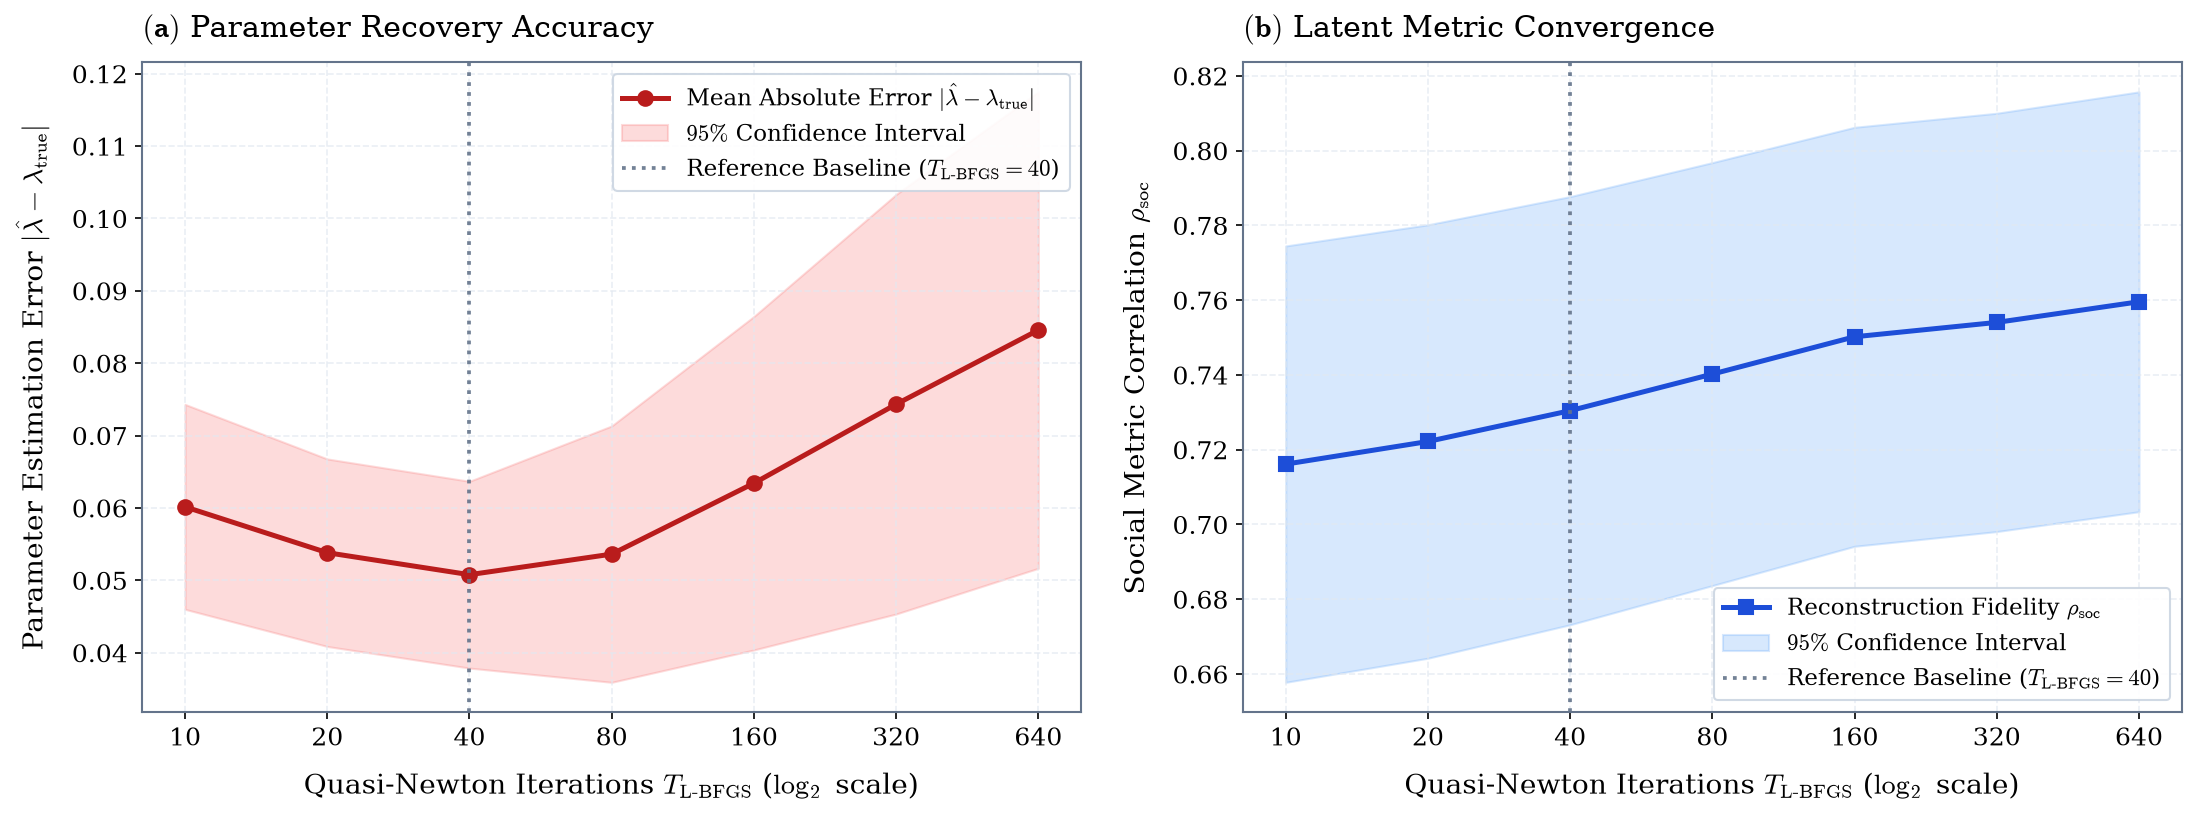


--- Summary Convergence Table ---


t_lbfgs   err_lam             rho_soc          
               mean       std      mean       std
0      10  0.060155  0.072222  0.716148  0.297791
1      20  0.053819  0.066086  0.722206  0.295810
2      40  0.050782  0.065829  0.730454  0.292199
3      80  0.053623  0.090360  0.740240  0.288664
4     160  0.063422  0.117531  0.750222  0.285950
5     320  0.074332  0.147860  0.754067  0.285491
6     640  0.084580  0.167931  0.759588  0.286521

In [24]:
# ======================================================================
# EXPERIMENT 3: QUASI-NEWTON CONVERGENCE (LOG2 SWEEP UP TO T=640)
# ======================================================================

import os
# Disabilita l'oversubscription di thread interni per i processi worker
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# --- 1. Scrittura modulo worker isolato (Compatibilità Python 3.14+ forkserver/spawn) ---
worker_code = '''import torch
import numpy as np
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr

# Limita PyTorch a 1 thread per processo worker
torch.set_num_threads(1)

def _lbfgs_worker(task):
    net_idx, t_lbfgs, net_item, ETA_ADAM, T_ADAM = task
    
    N = net_item["N"]
    c_target = net_item["c_target"]
    log_r0 = net_item["log_r0"]
    
    # Conversione locale sicura da array NumPy
    D_phys_t = torch.from_numpy(net_item["D_phys"]).float()
    W_obs_u  = torch.from_numpy(net_item["W_obs_u"]).float()
    iu_t     = torch.from_numpy(net_item["iu"]).long()
    ju_t     = torch.from_numpy(net_item["ju"]).long()
    eye_mask = torch.from_numpy(net_item["eye_mask"]).float()
    
    logit_lam = torch.tensor(0.0, requires_grad=True)
    log_r     = torch.tensor(log_r0, requires_grad=True)
    S_param   = torch.from_numpy(net_item["S_init"]).float().requires_grad_(True)
    
    # Fase A: Adam Warmup
    adam_opt = torch.optim.Adam([
        {"params": [logit_lam], "lr": ETA_ADAM * 2.0},
        {"params": [log_r],     "lr": ETA_ADAM},
        {"params": [S_param],   "lr": ETA_ADAM * 5.0}
    ])
    
    for _ in range(T_ADAM):
        adam_opt.zero_grad(set_to_none=True)
        lam = torch.sigmoid(logit_lam)
        r = torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0))
        
        K_sp = torch.exp(-D_phys_t / r) * eye_mask
        D_soc = torch.cdist(S_param, S_param)
        K_soc = torch.exp(-D_soc) * eye_mask
        
        W_raw_t = (1.0 - lam) * K_sp + lam * K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred_t = 0.5 * c_target * (W_raw_t / rs + W_raw_t / rs.t())
        
        wu = W_pred_t[iu_t, ju_t]
        loss = (wu - W_obs_u * torch.log(wu + 1e-12)).sum() + 0.5 * ((log_r - log_r0) / 2.0)**2
        loss.backward()
        adam_opt.step()
        
    # Fase B: L-BFGS
    lbfgs = torch.optim.LBFGS(
        [logit_lam, log_r, S_param],
        lr=0.5,
        max_iter=t_lbfgs,
        history_size=10,
        line_search_fn="strong_wolfe"
    )
    
    def closure():
        lbfgs.zero_grad(set_to_none=True)
        lam = torch.sigmoid(logit_lam)
        r = torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0))
        
        K_sp = torch.exp(-D_phys_t / r) * eye_mask
        D_soc = torch.cdist(S_param, S_param)
        K_soc = torch.exp(-D_soc) * eye_mask
        
        W_raw_t = (1.0 - lam) * K_sp + lam * K_soc
        rs = W_raw_t.sum(dim=1, keepdim=True) + 1e-12
        W_pred_t = 0.5 * c_target * (W_raw_t / rs + W_raw_t / rs.t())
        
        wu = W_pred_t[iu_t, ju_t]
        loss = (wu - W_obs_u * torch.log(wu + 1e-12)).sum() + 0.5 * ((log_r - log_r0) / 2.0)**2
        loss.backward()
        return loss
    
    try:
        lbfgs.step(closure)
        lam_hat = float(torch.sigmoid(logit_lam).item())
        err_lam = abs(lam_hat - net_item["lambda_true"])
        
        S_hat = S_param.detach().numpy()
        D_soc_hat = cdist(S_hat, S_hat)[net_item["iu"], net_item["ju"]]
        D_soc_gt  = net_item["D_soc_flat"]
        rho_soc, _ = pearsonr(D_soc_hat, D_soc_gt)
        if np.isnan(rho_soc):
            rho_soc = 0.0
    except Exception:
        err_lam = 1.0
        rho_soc = 0.0
        
    return {
        "network_idx": net_idx,
        "t_lbfgs": t_lbfgs,
        "err_lam": err_lam,
        "rho_soc": rho_soc
    }
'''

with open("_lbfgs_worker.py", "w") as f:
    f.write(worker_code)

from _lbfgs_worker import _lbfgs_worker

import time, numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.spatial.distance import cdist
from concurrent.futures import ProcessPoolExecutor
from IPython.display import display

# Output directory resolution
output_dir = "Robustness_tests" if os.path.basename(os.getcwd()) != "Robustness_tests" else "."
os.makedirs(output_dir, exist_ok=True)

# Typography & Publication Settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 13.5,
    "axes.titlesize": 14.5,
    "xtick.labelsize": 12.0,
    "ytick.labelsize": 12.0,
    "legend.fontsize": 11.0,
    "axes.edgecolor": "#64748b",
    "axes.linewidth": 1.0,
    "grid.color": "#e2e8f0",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "figure.dpi": 150
})

np.random.seed(42)

# --- Synthetic Network Generator ---
def sample_synthetic_network(N=None, lambda_true=None, r_true=None, sigma_true=None, d_s=2, seed=None):
    if seed is not None:
        np.random.seed(seed)
    if N is None:
        N = int(np.random.randint(100, 301))
    if lambda_true is None:
        lambda_true = float(np.random.uniform(0.05, 0.95))
    if r_true is None:
        r_true = float(np.exp(np.random.uniform(np.log(0.03), np.log(0.50))))
    if sigma_true is None:
        sigma_true = float(np.exp(np.random.uniform(np.log(0.03), np.log(0.50))))
    
    X_phys = np.random.uniform(0.0, 1.0, size=(N, 2))
    
    K = int(np.random.randint(2, 9))
    gmm_means = np.random.uniform(0.1, 0.9, size=(K, d_s))
    gmm_covs  = [np.diag(np.random.uniform(0.01, 0.05, size=d_s)) for _ in range(K)]
    weights   = np.random.dirichlet(np.ones(K))
    comp_choices = np.random.choice(K, size=N, p=weights)
    
    S_true = np.zeros((N, d_s))
    for k in range(K):
        idx_k = np.where(comp_choices == k)[0]
        if len(idx_k) > 0:
            S_true[idx_k] = np.random.multivariate_normal(gmm_means[k], gmm_covs[k], size=len(idx_k))
    S_min, S_max = S_true.min(axis=0), S_true.max(axis=0)
    S_true = (S_true - S_min) / (S_max - S_min + 1e-9)
    
    D_phys = cdist(X_phys, X_phys); np.fill_diagonal(D_phys, 1e9)
    D_soc  = cdist(S_true, S_true); np.fill_diagonal(D_soc, 1e9)
    
    K_sp  = np.exp(-D_phys / r_true);     np.fill_diagonal(K_sp, 0.0)
    K_soc = np.exp(-D_soc / sigma_true);  np.fill_diagonal(K_soc, 0.0)
    
    W_raw = (1.0 - lambda_true) * K_sp + lambda_true * K_soc
    row_sum = W_raw.sum(axis=1, keepdims=True) + 1e-12
    W_pred = 0.5 * (W_raw / row_sum + W_raw / row_sum.T)
    
    iu, ju = np.triu_indices(N, k=1)
    rate = N * W_pred[iu, ju]
    w_obs_u = np.random.poisson(rate).astype(float)
    
    W_obs = np.zeros((N, N))
    W_obs[iu, ju] = w_obs_u
    W_obs[ju, iu] = w_obs_u
    
    return {
        "N": N, "lambda_true": lambda_true, "r_true": r_true, "sigma_true": sigma_true,
        "D_phys": D_phys, "D_soc": D_soc, "S_true": S_true, "W_obs": W_obs
    }

# --- Sweep Parameters (Log2 progression up to 640) ---
N_BENCHMARK_NETWORKS = 100
t_lbfgs_list = [10, 20, 40, 80, 160, 320, 640]
ETA_ADAM = 0.04
T_ADAM = 50

tag = f"Log2_Nnets{N_BENCHMARK_NETWORKS}_Tadam{T_ADAM}_eta{ETA_ADAM:.2f}_Tlbfgs10-640"

print(f"Precomputing {N_BENCHMARK_NETWORKS} synthetic networks and static SVD initializations...")
ensemble_precomputed = []
for i in range(N_BENCHMARK_NETWORKS):
    net = sample_synthetic_network(seed=1000 + i)
    N = net["N"]; W = net["W_obs"]; D_phys = net["D_phys"]
    iu, ju = np.triu_indices(N, k=1)
    c_target = float(W.sum(axis=1).mean())
    r0 = float(2.0 * D_phys.min(axis=1).mean()); log_r0 = float(np.log(r0))
    
    K_sp0 = np.exp(-D_phys / r0); np.fill_diagonal(K_sp0, 0.0)
    s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
    W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
    R_init = np.maximum(0.0, W - W_sp0)
    U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
    S_init = U[:, :2] * np.sqrt(sv[:2])
    S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0
    
    ensemble_precomputed.append({
        "N": N, "lambda_true": net["lambda_true"], "c_target": c_target, "log_r0": log_r0,
        "D_phys": D_phys.astype(np.float32),
        "W_obs_u": W[iu, ju].astype(np.float32),
        "iu": iu.astype(np.int64), "ju": ju.astype(np.int64),
        "eye_mask": (1.0 - np.eye(N)).astype(np.float32),
        "S_init": S_init.astype(np.float32),
        "D_soc_flat": net["D_soc"][iu, ju].astype(np.float64)
    })

num_workers = os.cpu_count() or 4
print(f"Launching Log2 L-BFGS Sweep: {len(t_lbfgs_list)} steps on {num_workers} CPU workers...")
print(f"{'T_LBFGS (log2)':<16} | {'Mean |Δλ|':<12} | {'Mean ρ_soc':<12} | {'Step Time':<10} | {'Elapsed':<8}")
print("-" * 65)

t_start = time.time()
records_lbfgs = []

with ProcessPoolExecutor(max_workers=num_workers) as executor:
    for t_lbfgs in t_lbfgs_list:
        t_step = time.time()
        
        step_tasks = [
            (idx, t_lbfgs, net_item, ETA_ADAM, T_ADAM)
            for idx, net_item in enumerate(ensemble_precomputed)
        ]
        step_results = list(executor.map(_lbfgs_worker, step_tasks, chunksize=8))
        records_lbfgs.extend(step_results)
        
        mean_err = np.mean([r["err_lam"] for r in step_results])
        mean_rho = np.mean([r["rho_soc"] for r in step_results])
        step_duration = time.time() - t_step
        total_elapsed = time.time() - t_start
        
        print(f"T_L-BFGS = {t_lbfgs:<6d} | {mean_err:<12.4f} | {mean_rho:<12.4f} | {step_duration:<9.2f}s | {total_elapsed:<7.1f}s")

print("-" * 65)
print(f"Log2 Sweep completed in {time.time() - t_start:.2f}s.")

# --- Save CSVs & Integrity Verification ---
df_raw = pd.DataFrame(records_lbfgs)
raw_csv_path = os.path.join(output_dir, f"lbfgs_convergence_raw_{tag}.csv")
df_raw.to_csv(raw_csv_path, index=False)

df_summary = df_raw.groupby("t_lbfgs").agg({
    "err_lam": ["mean", "std"],
    "rho_soc": ["mean", "std"]
}).reset_index()

summary_csv_path = os.path.join(output_dir, f"lbfgs_convergence_summary_{tag}.csv")
df_summary.to_csv(summary_csv_path, index=False)

print("\n--- CSV Export Verification ---")
for p in [raw_csv_path, summary_csv_path]:
    if os.path.isfile(p):
        size_kb = os.path.getsize(p) / 1024
        print(f"  [OK] Saved: {os.path.basename(p):<60} ({size_kb:.1f} KB)")
    else:
        raise FileNotFoundError(f"Export check failed for {p}")

# --- Publication 2-Panel Log2 Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.8))
t_vals = np.array(t_lbfgs_list)

# ==========================================
# Panel 1: Parameter Estimation Accuracy
# ==========================================
ax1 = axes[0]
m_lam = df_summary["err_lam"]["mean"].values
s_lam = df_summary["err_lam"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)

ax1.plot(t_vals, m_lam, marker="o", color="#b91c1c", lw=2.4, markersize=7, label=r"Mean Absolute Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$")
ax1.fill_between(t_vals, m_lam - 1.96 * s_lam, m_lam + 1.96 * s_lam, color="#f87171", alpha=0.25, label=r"$95\%$ Confidence Interval")
ax1.axvline(40, color="#64748b", ls=":", lw=1.8, alpha=0.9, label=r"Reference Baseline ($T_{\mathrm{L\text{-}BFGS}} = 40$)")

ax1.set_xscale("log", base=2)
ax1.set_xticks(t_vals)
ax1.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax1.minorticks_off()

ax1.set_xlabel(r"Quasi-Newton Iterations $T_{\mathrm{L\text{-}BFGS}}$ ($\log_2$ scale)", labelpad=10)
ax1.set_ylabel(r"Parameter Estimation Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$", labelpad=10)
ax1.set_title(r"$\mathbf{(a)}$ Parameter Recovery Accuracy", loc="left", pad=12)
ax1.grid(True)
ax1.legend(loc="upper right", framealpha=0.9, edgecolor="#cbd5e1")

# ==========================================
# Panel 2: Latent Social Metric Recovery Fidelity
# ==========================================
ax2 = axes[1]
m_rho = df_summary["rho_soc"]["mean"].values
s_rho = df_summary["rho_soc"]["std"].values / np.sqrt(N_BENCHMARK_NETWORKS)

ax2.plot(t_vals, m_rho, marker="s", color="#1d4ed8", lw=2.4, markersize=7, label=r"Reconstruction Fidelity $\rho_{\mathrm{soc}}$")
ax2.fill_between(t_vals, m_rho - 1.96 * s_rho, m_rho + 1.96 * s_rho, color="#60a5fa", alpha=0.25, label=r"$95\%$ Confidence Interval")
ax2.axvline(40, color="#64748b", ls=":", lw=1.8, alpha=0.9, label=r"Reference Baseline ($T_{\mathrm{L\text{-}BFGS}} = 40$)")

ax2.set_xscale("log", base=2)
ax2.set_xticks(t_vals)
ax2.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax2.minorticks_off()

ax2.set_xlabel(r"Quasi-Newton Iterations $T_{\mathrm{L\text{-}BFGS}}$ ($\log_2$ scale)", labelpad=10)
ax2.set_ylabel(r"Social Metric Correlation $\rho_{\mathrm{soc}}$", labelpad=10)
ax2.set_title(r"$\mathbf{(b)}$ Latent Metric Convergence", loc="left", pad=12)
ax2.grid(True)
ax2.legend(loc="lower right", framealpha=0.9, edgecolor="#cbd5e1")

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color("#64748b")
        spine.set_linewidth(1.0)

plt.tight_layout(pad=2.0)

# Save publication figures
pdf_path = os.path.join(output_dir, f"lbfgs_convergence_2panel_log2_{tag}.pdf")
png_path = os.path.join(output_dir, f"lbfgs_convergence_2panel_log2_{tag}.png")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")

print("\n--- Figure Export Verification ---")
for fpath in [pdf_path, png_path]:
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  [OK] Saved: {os.path.basename(fpath):<60} ({size_kb:.1f} KB)")
    else:
        raise FileNotFoundError(f"Export check failed for {fpath}")

plt.show()

print("\n--- Summary Convergence Table ---")
display(df_summary)

Caricamento dati da: ./lbfgs_convergence_raw_Log2_Nnets100_Tadam50_eta0.04_Tlbfgs10-640.csv

--- Figure Export Verification ---
  [OK] Saved: lbfgs_convergence_vertical_log2_Log2_Nnets100_Tadam50_eta0.04_Tlbfgs10-640.pdf (37.6 KB)
  [OK] Saved: lbfgs_convergence_vertical_log2_Log2_Nnets100_Tadam50_eta0.04_Tlbfgs10-640.png (394.6 KB)


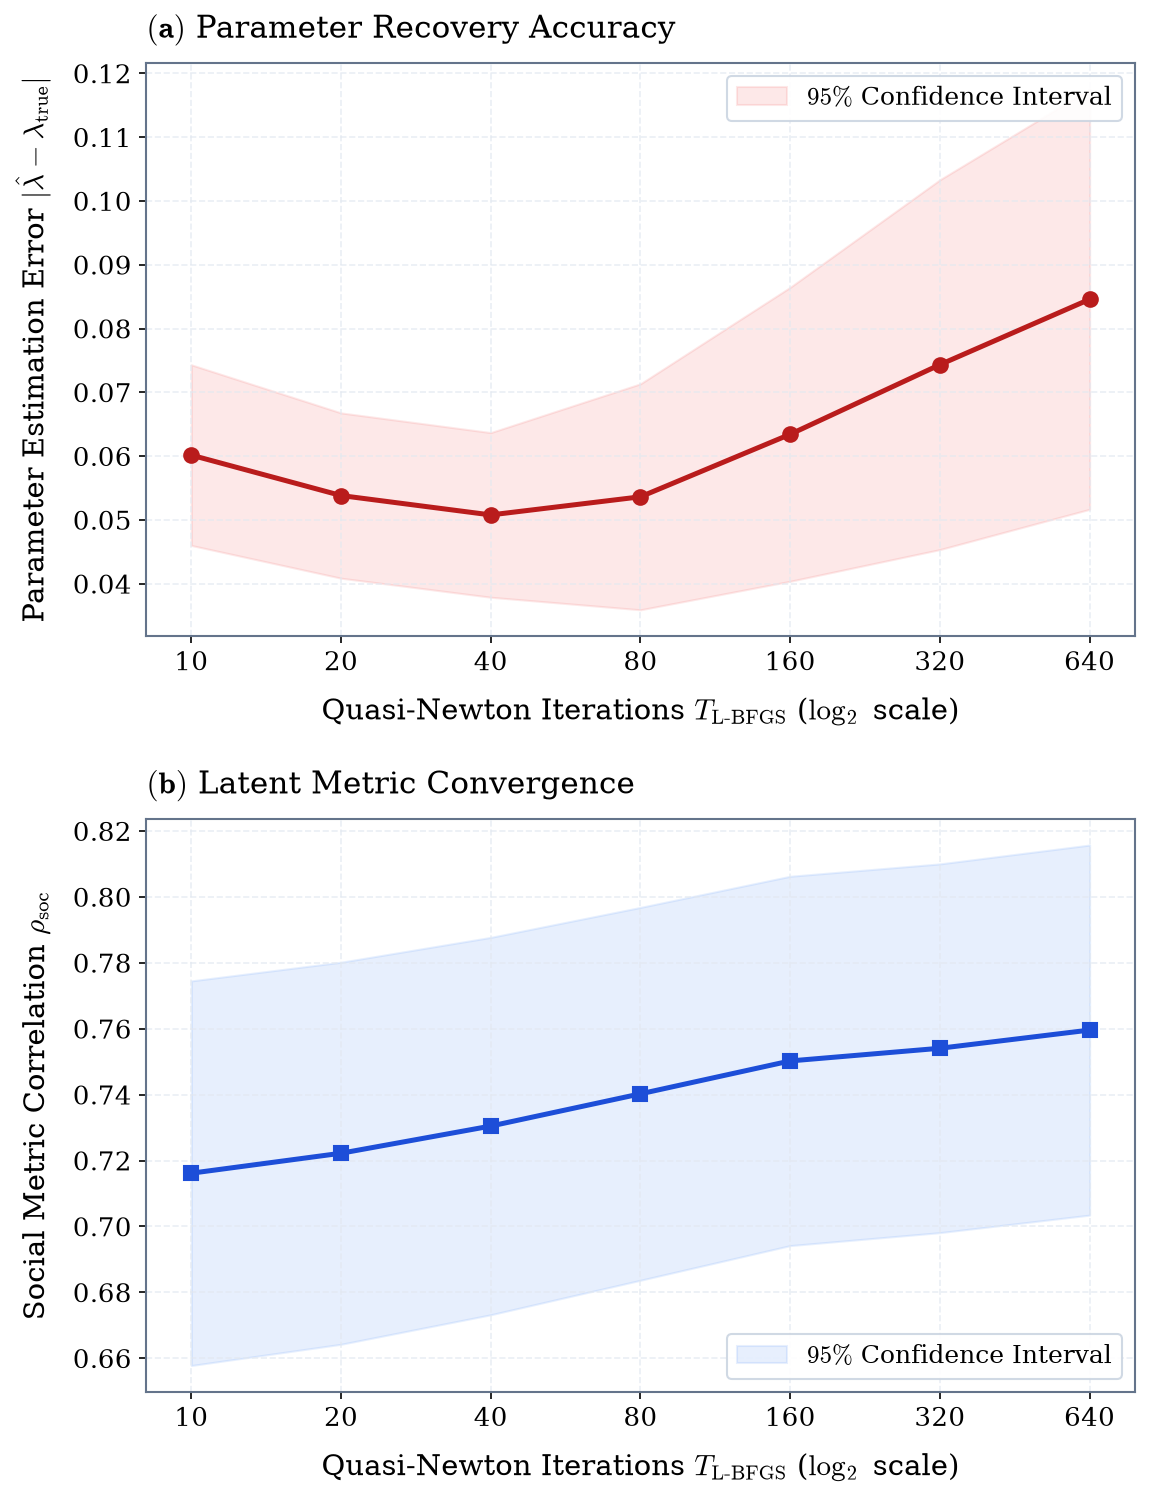


--- Summary Table ---


t_lbfgs   err_lam                   rho_soc                
               mean       std count      mean       std count
0      10  0.060155  0.072222   100  0.716148  0.297791   100
1      20  0.053819  0.066086   100  0.722206  0.295810   100
2      40  0.050782  0.065829   100  0.730454  0.292199   100
3      80  0.053623  0.090360   100  0.740240  0.288664   100
4     160  0.063422  0.117531   100  0.750222  0.285950   100
5     320  0.074332  0.147860   100  0.754067  0.285491   100
6     640  0.084580  0.167931   100  0.759588  0.286521   100

In [26]:
# ======================================================================
# RE-PLOT VERTICAL 2-PANEL LOG2 CONVERGENCE (LOWER SHADING ALPHA)
# ======================================================================

import os, glob
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

# Output directory resolution
output_dir = "Robustness_tests" if os.path.basename(os.getcwd()) != "Robustness_tests" else "."

# --- 1. Grid Parameters & CSV Resolution ---
N_BENCHMARK_NETWORKS = 100
T_ADAM = 50
ETA_ADAM = 0.04
t_lbfgs_list = [10, 20, 40, 80, 160, 320, 640]

tag = f"Log2_Nnets{N_BENCHMARK_NETWORKS}_Tadam{T_ADAM}_eta{ETA_ADAM:.2f}_Tlbfgs10-640"
raw_csv_path = os.path.join(output_dir, f"lbfgs_convergence_raw_{tag}.csv")

if not os.path.exists(raw_csv_path):
    candidates = glob.glob(os.path.join(output_dir, "lbfgs_convergence_raw_*.csv"))
    if candidates:
        raw_csv_path = max(candidates, key=os.path.getmtime)
        print(f"Caricamento automatico dall'ultimo CSV disponibile: {raw_csv_path}")
    else:
        raise FileNotFoundError(f"Nessun file CSV raw trovato in '{output_dir}/'.")
else:
    print(f"Caricamento dati da: {raw_csv_path}")

df_raw = pd.read_csv(raw_csv_path)

# --- 2. Statistical Aggregation ---
df_summary = df_raw.groupby("t_lbfgs").agg({
    "err_lam": ["mean", "std", "count"],
    "rho_soc": ["mean", "std", "count"]
}).reset_index()

t_vals = df_summary["t_lbfgs"].values
n_nets = df_summary["err_lam"]["count"].values

m_lam = df_summary["err_lam"]["mean"].values
s_lam = df_summary["err_lam"]["std"].values / np.sqrt(n_nets)

m_rho = df_summary["rho_soc"]["mean"].values
s_rho = df_summary["rho_soc"]["std"].values / np.sqrt(n_nets)

# --- 3. Plotting Setup ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 14.0,
    "axes.titlesize": 15.0,
    "xtick.labelsize": 12.5,
    "ytick.labelsize": 12.5,
    "legend.fontsize": 12.0,
    "axes.edgecolor": "#64748b",
    "axes.linewidth": 1.0,
    "grid.color": "#e2e8f0",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "figure.dpi": 150
})

fig, axes = plt.subplots(2, 1, figsize=(8.5, 11.5))

# ==========================================
# Panel 1 (Top): Parameter Estimation Accuracy
# ==========================================
ax1 = axes[0]
ax1.plot(t_vals, m_lam, marker="o", color="#b91c1c", lw=2.4, markersize=7)
ax1.fill_between(t_vals, m_lam - 1.96 * s_lam, m_lam + 1.96 * s_lam, 
                 color="#ef4444", alpha=0.12, label=r"$95\%$ Confidence Interval")

ax1.set_xscale("log", base=2)
ax1.set_xticks(t_vals)
ax1.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax1.minorticks_off()

ax1.set_xlabel(r"Quasi-Newton Iterations $T_{\mathrm{L\text{-}BFGS}}$ ($\log_2$ scale)", labelpad=10)
ax1.set_ylabel(r"Parameter Estimation Error $|\hat{\lambda} - \lambda_{\mathrm{true}}|$", labelpad=10)
ax1.set_title(r"$\mathbf{(a)}$ Parameter Recovery Accuracy", loc="left", pad=12)
ax1.grid(True)
ax1.legend(loc="upper right", framealpha=0.9, edgecolor="#cbd5e1")

# ==========================================
# Panel 2 (Bottom): Latent Social Metric Recovery Fidelity
# ==========================================
ax2 = axes[1]
ax2.plot(t_vals, m_rho, marker="s", color="#1d4ed8", lw=2.4, markersize=7)
ax2.fill_between(t_vals, m_rho - 1.96 * s_rho, m_rho + 1.96 * s_rho, 
                 color="#3b82f6", alpha=0.12, label=r"$95\%$ Confidence Interval")

ax2.set_xscale("log", base=2)
ax2.set_xticks(t_vals)
ax2.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax2.minorticks_off()

ax2.set_xlabel(r"Quasi-Newton Iterations $T_{\mathrm{L\text{-}BFGS}}$ ($\log_2$ scale)", labelpad=10)
ax2.set_ylabel(r"Social Metric Correlation $\rho_{\mathrm{soc}}$", labelpad=10)
ax2.set_title(r"$\mathbf{(b)}$ Latent Metric Convergence", loc="left", pad=12)
ax2.grid(True)
ax2.legend(loc="lower right", framealpha=0.9, edgecolor="#cbd5e1")

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color("#64748b")
        spine.set_linewidth(1.0)

plt.subplots_adjust(hspace=0.32)

# --- 4. Export PDF & PNG ---
pdf_path = os.path.join(output_dir, f"lbfgs_convergence_vertical_log2_{tag}.pdf")
png_path = os.path.join(output_dir, f"lbfgs_convergence_vertical_log2_{tag}.png")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, bbox_inches="tight")

print("\n--- Figure Export Verification ---")
for fpath in [pdf_path, png_path]:
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  [OK] Saved: {os.path.basename(fpath):<60} ({size_kb:.1f} KB)")

plt.show()

print("\n--- Summary Table ---")
display(df_summary[["t_lbfgs", "err_lam", "rho_soc"]])